# **How Curvature, Dimensionality and Distributional Complexity Affect Riemannian Flow Matching**

## **Results**

- All helper utilities live in `visualize_run.py` (paths/globs, metrics I/O, and plotting).
- A run directory is expected to contain `artifacts/final_fixed_eval_outputs.pt` and `metrics.json`.

In [1]:
from visualize_run import get_metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import matplotlib.pyplot as plt

# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Georgia", "DejaVu Serif", "Times New Roman"],
#     "mathtext.fontset": "dejavuserif",
#     "axes.titlesize": 14,
#     "axes.labelsize": 14,
#     "xtick.labelsize": 14,
#     "ytick.labelsize": 14,
#     "legend.fontsize": 14,
#     "figure.titlesize": 14,
#     "axes.spines.top": False,
#     "axes.spines.right": False,
# })

import matplotlib as mpl
# mpl.rcParams.update({
#     "text.usetex": True, # LaTeX compiler; comment out for faster rendering
#     # "text.latex.preamble": r"\usepackage{amsmath}\usepackage{bm}",
#     "font.family" : "serif",
#     "font.serif" : ["Latin Modern Roman"],
#     "mathtext.fontset" : "cm",
#     "axes.labelsize" : 14,
#     "font.size" : 14,
#     "xtick.labelsize" : 14,
#     "ytick.labelsize" : 14,
#     "axes.titlesize": 14,
#     "legend.fontsize": 14,
#     "figure.titlesize": 14,
#     "axes.spines.top": True,
#     "axes.spines.right": True,
# })

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
    "font.size": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 14,
    "axes.spines.top": True,
    "axes.spines.right": True,
})

### Define output paths
- Specify output globs where outputs live

In [4]:
mog_paths = [
    '../outputs/runs/mog/euclidean/general/*',
    '../outputs/runs/mog/sphere/general/*',
    '../outputs/runs/mog/poincare/general/*',
]

gtg_paths = [
    '../outputs/runs/gtg/euclidean/general/*',
    '../outputs/runs/gtg/sphere/general/*',
    '../outputs/runs/gtg/poincare/general/*'
]

gaussian_ring_paths = [
    '../outputs/runs/general_fm/fm/*/*'
]

checkerboard_paths = [
    '../outputs/runs/checkerboard/euclidean/general/*',
    '../outputs/runs/checkerboard/sphere/general/*',
    '../outputs/runs/checkerboard/poincare/general/*',
]

gtg_norm_paths = [
    '../outputs/runs/gtg/euclidean/norm/*',
    '../outputs/runs/gtg/sphere/norm/*',
    '../outputs/runs/gtg/poincare/norm/*',
]

### Load results
- Set visualize to True to save plots of final flow matching distribution.
- Results are saved to csv by default.
- Comment out ```get_method()``` lines to load results from csv.

In [5]:
# Load and save into csv (comment out if applicable)
# metrics_gtg = get_metrics([], gtg_paths, visualize=False, save=True, out_dir='runs/gtg')
# metrics_mog = get_metrics([], mog_paths, visualize=False, save=True, out_dir='runs/mog')
# metrics_gaussian_ring = get_metrics([], gaussian_ring_paths, visualize=False, save=True, out_dir='runs/gaussian_ring')
# metrics_checkerboard = get_metrics([], checkerboard_paths, visualize=False, save=True, out_dir='runs/checkerboard')

# Retrieve from csv
metrics_gtg = pd.read_csv('runs/gtg/metrics.csv')
metrics_gtg_norm = pd.read_csv('runs/gtg_norm/metrics.csv')
metrics_mog = pd.read_csv('runs/mog/metrics.csv')
metrics_gaussian_ring = pd.read_csv('runs/gaussian_ring/metrics.csv')
metrics_checkerboard = pd.read_csv('runs/checkerboard/metrics.csv')

### Specify Results
- Change the experiment variable to applicable experiment
- change the x or y axis to get metrics

In [6]:
def print_metrics(experiment: pd.DataFrame, x: str, y: str):
    print(f"Available metrics:")
    print(", ".join(map(str, experiment.columns.tolist())))
    print()
    
    selected = experiment[[experiment.columns[0], x, y]]
    print(selected.to_string(index=False))

In [7]:
# metrics_gtg, metrics_mog, metrics_gaussian_ring, metrics_checkerboard
print_metrics(metrics_gtg, x='test_sample/volume_scaling_gap_target_minus_pred', y='test_sample/sinkhorn_knopp')

Available metrics:
Unnamed: 0, train/loss, train/loss_step, train/loss_epoch, nfe, integ_error, test/loss, test_vec/rfm_loss, test_vec/alignment, test_vec/finite_fraction, test_vec/norm_mean, test_vec/norm_max, test_vec/norm_std, test_vec/norm_p95, test_vec/tangency_violation_abs, test_vec/tangency_violation_rel, test_sample/sinkhorn_knopp, test_sample/tangent_sinkhorn_knopp, test_sample/tangent_to_geodesic_sinkhorn_ratio, test_sample/epsilon_coverage, test_sample/epsilon_precision, test_sample/frechet_variance_pred, test_sample/frechet_variance_target, test_sample/frechet_variance_ratio, test_sample/dispersion_predicted, test_sample/dispersion_target, test_sample/dispersion_ratio, test_sample/volume_scaling_mean_pred, test_sample/volume_scaling_mean_target, test_sample/volume_scaling_variance_pred, test_sample/volume_scaling_variance_target, test_sample/volume_scaling_gap_target_minus_pred, test_sample/volume_scaling_mean_start, test_sample/volume_scaling_variance_start, test_sample/v

In [10]:
# # average over seeds (manifold, curvature, dim are equal)
# experiment_avg = experiment.groupby(['manifold', 'dim', 'curvature'], as_index=False).mean(numeric_only=True)
# print(experiment_avg)

In [11]:
# # Convert ambient dimension to intrinsic dimension for sphere (dim - 1)
# experiment_avg_intr = experiment_avg.copy()
# experiment_avg_intr.loc[experiment_avg_intr['manifold'] == 'sphere', 'dim'] -= 1
# print(experiment_avg_intr)

### Plots RQ 1
**Main**

In [12]:
# # change all the VGG for sphere to negative
# experiment_avg_intr_vgg = experiment_avg_intr.copy()
# experiment_avg_intr_vgg.loc[experiment_avg_intr_vgg['manifold'] == 'sphere', 'test_sample/volume_scaling_gap_target_minus_pred'] *= 1

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": True,                # Comment out if LaTeX rendering is slow/unavailable
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 16,
    "font.size": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})


# ============================================================
# User settings
# ============================================================

PERF_COL = "test_sample/sinkhorn_knopp"
VGG_COL = "test_sample/volume_scaling_gap_target_minus_pred"

DIM_COL = "dim"
MANIFOLD_COL = "manifold"
CURV_COL = "curvature"

EUCLIDEAN_NAME = "euclidean"
POINCARE_NAME = "poincare"
SPHERE_NAME = "sphere"

SPHERE_DIM_MINUS_ONE = True

ERROR_BAR = "sem"
LABEL_POINTS = True

CURVATURE_ORDER = "abs"

# Compact inside-plot legend settings
LEGEND_FONTSIZE = 14
LEGEND_FRAME_ALPHA = 0.85


# ============================================================
# Helper functions
# ============================================================

def signed_log1p(x):
    """Signed log transform: keeps sign, handles zero, compresses large values."""
    return np.sign(x) * np.log10(1 + np.abs(x))


def error_value(x, kind="sem"):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()

    if len(x) <= 1:
        return 0.0

    if kind == "std":
        return x.std(ddof=1)

    if kind == "sem":
        return x.std(ddof=1) / np.sqrt(len(x))

    return 0.0


def nice_dim_label(x):
    if pd.isna(x):
        return ""
    if float(x).is_integer():
        return str(int(x))
    return f"{x:g}"


def nice_curv_label(x):
    if pd.isna(x):
        return "NA"
    try:
        return f"{float(x):g}"
    except Exception:
        return str(x)


def display_manifold_name(m):
    if m == POINCARE_NAME:
        return "Hyperbolic"
    if m == SPHERE_NAME:
        return "Spherical"
    if m == EUCLIDEAN_NAME:
        return "Euclidean"
    return str(m)


def ordered_curvatures(values, order="abs"):
    values = pd.Series(values).dropna().unique()

    def sort_key(x):
        try:
            x_float = float(x)

            if order == "abs":
                return (abs(x_float), x_float)

            if order == "numeric":
                return (x_float,)

        except Exception:
            pass

        return (str(x),)

    return sorted(values, key=sort_key)


def ordered_manifolds(values):
    preferred_order = [POINCARE_NAME, SPHERE_NAME, EUCLIDEAN_NAME]
    values = list(pd.Series(values).dropna().unique())

    ordered = [m for m in preferred_order if m in values]
    ordered += [m for m in values if m not in ordered]

    return ordered


def add_inside_legend(
    ax,
    loc="best",
    title=None,
    ncol=1,
    fontsize=LEGEND_FONTSIZE,
):
    """Compact legend placed inside the plotting area."""

    legend = ax.legend(
        loc=loc,
        frameon=True,
        framealpha=LEGEND_FRAME_ALPHA,
        fontsize=fontsize,
        title=title,
        title_fontsize=fontsize,
        ncol=ncol,
        handlelength=1.0,
        handletextpad=0.25,
        columnspacing=0.55,
        labelspacing=0.15,
        borderpad=0.25,
        borderaxespad=0.25,
        markerscale=0.85,
    )

    return legend


def add_grouped_curvature_legends(
    ax,
    specs,
    hyp_loc="upper right",
    sph_loc="center right",
    fontsize=LEGEND_FONTSIZE,
):
    """
    Adds two compact inside legends:
    one for Hyperbolic curvatures and one for Spherical curvatures.

    This avoids repeating 'Hyp' and 'Sph' on every legend entry.
    """

    hyp_handles, hyp_labels = [], []
    sph_handles, sph_labels = [], []

    for spec in specs["group_specs"]:
        handle = plt.Line2D(
            [0],
            [0],
            color=spec["color"],
            marker=spec["marker"],
            linestyle=spec["linestyle"],
            linewidth=1.5,
            markersize=6,
        )

        label = rf"$\kappa={nice_curv_label(spec['curvature'])}$"

        if spec["manifold"] == POINCARE_NAME:
            hyp_handles.append(handle)
            hyp_labels.append(label)

        elif spec["manifold"] == SPHERE_NAME:
            sph_handles.append(handle)
            sph_labels.append(label)

    hyp_legend = None
    sph_legend = None

    if hyp_handles:
        hyp_legend = ax.legend(
            hyp_handles,
            hyp_labels,
            title=r"$\mathrm{Hyp}$",
            loc=hyp_loc,
            frameon=True,
            framealpha=LEGEND_FRAME_ALPHA,
            fontsize=fontsize,
            title_fontsize=fontsize,
            ncol=1,
            handlelength=1.0,
            handletextpad=0.25,
            labelspacing=0.12,
            borderpad=0.22,
            borderaxespad=0.25,
            markerscale=0.85,
        )
        ax.add_artist(hyp_legend)

    if sph_handles:
        sph_legend = ax.legend(
            sph_handles,
            sph_labels,
            title=r"$\mathrm{Sph}$",
            loc=sph_loc,
            frameon=True,
            framealpha=LEGEND_FRAME_ALPHA,
            fontsize=fontsize,
            title_fontsize=fontsize,
            ncol=1,
            handlelength=1.0,
            handletextpad=0.25,
            labelspacing=0.12,
            borderpad=0.22,
            borderaxespad=0.25,
            markerscale=0.85,
        )

    return hyp_legend, sph_legend


# ============================================================
# Data preparation
# ============================================================

def prepare_rq1_dataframe(df):
    """
    Adds:
    - compare_dim
    - Euclidean baselines per dimension
    - log relative performance wrt Euclidean
    - signed-log VGG gap wrt Euclidean
    """

    df = df.copy()

    df[PERF_COL] = pd.to_numeric(df[PERF_COL], errors="coerce")
    df[VGG_COL] = pd.to_numeric(df[VGG_COL], errors="coerce")
    df[DIM_COL] = pd.to_numeric(df[DIM_COL], errors="coerce")

    df["compare_dim"] = df[DIM_COL]

    if SPHERE_DIM_MINUS_ONE:
        is_sphere = df[MANIFOLD_COL].eq(SPHERE_NAME)
        df.loc[is_sphere, "compare_dim"] = df.loc[is_sphere, DIM_COL] - 1

    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(
            euc_perf=(PERF_COL, "mean"),
            euc_vgg=(VGG_COL, "mean"),
        )
    )

    euc["euc_vgg"] = euc["euc_vgg"].fillna(0.0)

    df = df.merge(euc, on="compare_dim", how="left")

    df["rel_perf"] = df[PERF_COL] / df["euc_perf"]
    df["log_rel_perf"] = np.log10(df["rel_perf"])

    df["vgg_gap_vs_euc"] = df[VGG_COL] - df["euc_vgg"]
    df["signed_log_vgg_gap"] = signed_log1p(df["vgg_gap_vs_euc"])

    return df


def summarize_for_curvature_plot(df_prepared):
    """
    Averages over seeds for each:
        dimension × manifold × curvature
    """

    plot_df = df_prepared[
        ~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)
    ].copy()

    group_cols = ["compare_dim", MANIFOLD_COL, CURV_COL]

    rows = []

    for keys, sub in plot_df.groupby(group_cols, dropna=False):
        compare_dim, manifold, curvature = keys

        row = {
            "compare_dim": compare_dim,
            MANIFOLD_COL: manifold,
            CURV_COL: curvature,
        }

        y = sub["log_rel_perf"].replace([np.inf, -np.inf], np.nan).dropna()
        row["log_rel_perf_mean"] = y.mean()
        row["log_rel_perf_err"] = error_value(y, ERROR_BAR)
        row["log_rel_perf_n"] = len(y)
        row["perf_mean"] = sub[PERF_COL].mean()
        row["perf"] = sub[PERF_COL]
        row["perf_err"] = error_value(sub[PERF_COL], ERROR_BAR)

        x = sub["signed_log_vgg_gap"].replace([np.inf, -np.inf], np.nan).dropna()
        row["signed_log_vgg_gap_mean"] = x.mean()
        row["signed_log_vgg_gap_err"] = error_value(x, ERROR_BAR)
        row["signed_log_vgg_gap_n"] = len(x)

        rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# Shared plotting helpers
# ============================================================

def get_rq1_style_specs(summary):
    marker_map = {
        POINCARE_NAME: "X",
        SPHERE_NAME: "1",
    }

    line_map = {
        POINCARE_NAME: "solid",
        SPHERE_NAME: "dashed",
    }

    manifold_cmap_map = {
        POINCARE_NAME: plt.cm.YlOrBr,
        SPHERE_NAME: plt.cm.BuGn,
    }

    pooled_color_map = {
        POINCARE_NAME: plt.cm.YlOrBr(0.75),
        SPHERE_NAME: plt.cm.BuGn(0.75),
    }

    manifolds = ordered_manifolds(summary[MANIFOLD_COL])
    curvatures = ordered_curvatures(summary[CURV_COL], order=CURVATURE_ORDER)

    curvature_color_map = {}

    for manifold in manifolds:
        manifold_curvatures = ordered_curvatures(
            summary.loc[summary[MANIFOLD_COL].eq(manifold), CURV_COL],
            order=CURVATURE_ORDER,
        )

        cmap = manifold_cmap_map.get(manifold, plt.cm.viridis)
        color_positions = np.linspace(0.35, 0.9, max(len(manifold_curvatures), 1))

        for i, curvature in enumerate(manifold_curvatures):
            curvature_color_map[(manifold, curvature)] = cmap(color_positions[i])

    group_specs = []

    for manifold in manifolds:
        for curvature in curvatures:
            sub = summary[
                summary[MANIFOLD_COL].eq(manifold)
                & summary[CURV_COL].eq(curvature)
            ].copy()

            if sub.empty:
                continue

            group_specs.append({
                "sub": sub,
                "label": rf"$\kappa={nice_curv_label(curvature)}$",
                "color": curvature_color_map.get((manifold, curvature), "C0"),
                "marker": marker_map.get(manifold, "o"),
                "linestyle": line_map.get(manifold, "solid"),
                "manifold": manifold,
                "curvature": curvature,
            })

    return {
        "marker_map": marker_map,
        "line_map": line_map,
        "pooled_color_map": pooled_color_map,
        "manifolds": manifolds,
        "curvatures": curvatures,
        "group_specs": group_specs,
    }


def pooled_mean_error(sub, mean_col, err_col):
    vals = sub[mean_col].replace([np.inf, -np.inf], np.nan).dropna()

    if len(vals) == 0:
        return np.nan, np.nan, 0

    mean = vals.mean()

    if len(vals) > 1:
        between_std = vals.std(ddof=1)

        if ERROR_BAR == "sem":
            between_err = between_std / np.sqrt(len(vals))
        else:
            between_err = between_std
    else:
        between_err = 0.0

    if err_col in sub.columns:
        within_errs = sub.loc[vals.index, err_col].replace(
            [np.inf, -np.inf],
            np.nan,
        ).dropna()

        if len(within_errs) > 0:
            within_err = np.sqrt(np.mean(within_errs ** 2))
        else:
            within_err = 0.0
    else:
        within_err = 0.0

    combined_err = np.sqrt(between_err ** 2 + within_err ** 2)

    return mean, combined_err, len(vals)


def make_panel_a_pooled_df(summary):
    panel_a_rows = []

    for (dim, manifold), sub in summary.groupby(["compare_dim", MANIFOLD_COL]):
        x_mean, x_err, x_n = pooled_mean_error(
            sub,
            mean_col="signed_log_vgg_gap_mean",
            err_col="signed_log_vgg_gap_err",
        )

        y_mean, y_err, y_n = pooled_mean_error(
            sub,
            mean_col="log_rel_perf_mean",
            err_col="log_rel_perf_err",
        )

        if pd.isna(x_mean) or pd.isna(y_mean):
            continue

        panel_a_rows.append({
            "compare_dim": dim,
            MANIFOLD_COL: manifold,
            "x_mean": x_mean,
            "x_err": x_err,
            "y_mean": y_mean,
            "y_err": y_err,
            "n_curvatures": min(x_n, y_n),
        })

    return pd.DataFrame(panel_a_rows)


def format_dimension_axis(ax, summary):
    dims = sorted(summary["compare_dim"].dropna().unique())

    ax.set_xscale("log", base=2)
    ax.set_xticks(dims)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())


def annotate_dimension_labels_panel_a(ax, sub):
    """
    Stagger dimension labels to reduce overlap, especially in the top-right cluster.
    """

    if sub.empty:
        return

    sub = sub.copy().sort_values(["y_mean", "x_mean"]).reset_index(drop=True)

    x_hi = sub["x_mean"].quantile(0.65)
    y_hi = sub["y_mean"].quantile(0.65)

    normal_offsets = [
        (6, 7),
        (8, -12),
        (-18, 8),
        (-20, -12),
        (12, 16),
        (-28, 16),
    ]

    top_right_offsets = [
        (-28, 12),
        (-38, -10),
        (-48, 4),
        (-32, 24),
        (-54, -22),
        (-62, 16),
    ]

    for i, row in sub.iterrows():
        is_top_right = (row["x_mean"] >= x_hi) and (row["y_mean"] >= y_hi)

        if is_top_right:
            xytext = top_right_offsets[i % len(top_right_offsets)]
            ha = "right"
            arrowprops = dict(
                arrowstyle="-",
                linewidth=0.45,
                color="0.35",
                alpha=0.65,
                shrinkA=0,
                shrinkB=3,
            )
        else:
            xytext = normal_offsets[i % len(normal_offsets)]
            ha = "left" if xytext[0] >= 0 else "right"
            arrowprops = None

        ax.annotate(
            rf"$d={nice_dim_label(row['compare_dim'])}$",
            xy=(row["x_mean"], row["y_mean"]),
            xytext=xytext,
            textcoords="offset points",
            fontsize=9,
            alpha=0.95,
            ha=ha,
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.12",
                facecolor="white",
                edgecolor="none",
                alpha=0.72,
            ),
            arrowprops=arrowprops,
            zorder=10,
        )


# ============================================================
# Plot 1: volume gap vs relative performance
# ============================================================

def plot_rq1_volume_gap_vs_performance(
    summary,
    figsize=(6.4, 5.0),
    legend_loc="lower right",
):
    specs = get_rq1_style_specs(summary)
    panel_a_df = make_panel_a_pooled_df(summary)

    fig, ax = plt.subplots(figsize=figsize)

    for manifold in specs["manifolds"]:
        sub = panel_a_df[panel_a_df[MANIFOLD_COL].eq(manifold)].copy()

        if sub.empty:
            continue

        ax.errorbar(
            sub["x_mean"],
            sub["y_mean"],
            xerr=sub["x_err"],
            yerr=sub["y_err"],
            fmt=specs["marker_map"].get(manifold, "o"),
            color=specs["pooled_color_map"].get(manifold, "C0"),
            markersize=8,
            capsize=3,
            linestyle="none",
            alpha=0.9,
            label=rf"{display_manifold_name(manifold)}, pooled over $\kappa$",
        )

    ax.margins(x=0.12, y=0.15)

    if LABEL_POINTS:
        for manifold in specs["manifolds"]:
            sub = panel_a_df[panel_a_df[MANIFOLD_COL].eq(manifold)].copy()
            annotate_dimension_labels_panel_a(ax, sub)

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    ax.set_title(r"Volume gap vs relative performance")
    ax.set_xlabel(
        r"$\mathrm{sgn}(\Delta\mathrm{VGG})"
        r"\,\log_{10}\!\left(1 + |\Delta\mathrm{VGG}|\right)$"
        "\n"
        r"$\Delta\mathrm{VGG}=\mathrm{VGG}_{\mathcal{M}}-\mathrm{VGG}_{\mathrm{Euc}}$"
    )
    ax.set_ylabel(
        r"$\log_{10}\!\left(\mathcal{W}_{\mathcal{M}}"
        r"/\mathcal{W}_{\mathrm{Euc}}\right)$"
    )

    # ax.text(
    #     0.02,
    #     0.02,
    #     r"Point labels: $d$" "\n" r"Curvatures pooled within manifold",
    #     transform=ax.transAxes,
    #     fontsize=14,
    #     va="bottom",
    #     ha="left",
    # )

    ax.grid(alpha=0.2)

    add_inside_legend(
        ax,
        loc=legend_loc,
        ncol=1,
        fontsize=LEGEND_FONTSIZE,
    )

    fig.tight_layout()

    return fig, ax, panel_a_df


# ============================================================
# Plot 2: dimension vs relative performance
# ============================================================

def plot_rq1_dimension_vs_performance(
    summary,
    figsize=(6.4, 5.0),
    hyp_legend_loc="upper right",
    sph_legend_loc="center right",
):
    specs = get_rq1_style_specs(summary)

    fig, ax = plt.subplots(figsize=figsize)

    for spec in specs["group_specs"]:
        sub = spec["sub"].dropna(
            subset=["compare_dim", "log_rel_perf_mean"]
        ).sort_values("compare_dim")

        if sub.empty:
            continue

        ax.errorbar(
            sub["compare_dim"],
            sub["log_rel_perf_mean"],
            yerr=sub["log_rel_perf_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.85,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    format_dimension_axis(ax, summary)

    ax.set_title(r"Relative performance across dimension")
    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(
        r"$\log_{10}\!\left(\mathcal{W}_{\mathcal{M}}"
        r"/\mathcal{W}_{\mathrm{Euc}}\right)$"
    )

    # ax.text(
    #     0.02,
    #     0.02,
    #     r"$>0$: worse than Euclidean" "\n" r"$<0$: better than Euclidean",
    #     transform=ax.transAxes,
    #     fontsize=14,
    #     va="top",
    #     ha="center",
    # )

    ax.grid(alpha=0.2)

    add_grouped_curvature_legends(
        ax,
        specs,
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=LEGEND_FONTSIZE,
    )

    fig.tight_layout()

    return fig, ax


# ============================================================
# Plot 3: dimension vs volume-growth gap
# ============================================================

def plot_rq1_dimension_vs_vgg(
    summary,
    figsize=(3 * 1.618, 3),
    hyp_legend_loc="upper right",
    sph_legend_loc="center right",
):
    specs = get_rq1_style_specs(summary)

    fig, ax = plt.subplots(figsize=figsize)

    for spec in specs["group_specs"]:
        sub = spec["sub"].dropna(
            subset=["compare_dim", "signed_log_vgg_gap_mean"]
        ).sort_values("compare_dim")

        if sub.empty:
            continue

        ax.errorbar(
            sub["compare_dim"],
            sub["signed_log_vgg_gap_mean"],
            yerr=sub["signed_log_vgg_gap_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.85,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    format_dimension_axis(ax, summary)

    ax.set_title(r"Volume-growth gap across dimension")
    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(
        r"$\mathrm{sgn}(\Delta\mathrm{VGG})"
        r"\,\log_{10}\!\left(1 + |\Delta\mathrm{VGG}|\right)$"
    )

    # ax.text(
    #     0.02,
    #     0.02,
    #     r"Euclidean baseline: $\Delta\mathrm{VGG}=0$"
    #     "\n"
    #     r"Undefined VGG omitted",
    #     transform=ax.transAxes,
    #     fontsize=14,
    #     va="bottom",
    #     ha="left",
    # )

    ax.grid(alpha=0.2)

    add_grouped_curvature_legends(
        ax,
        specs,
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=LEGEND_FONTSIZE,
    )

    fig.tight_layout()

    return fig, ax

In [9]:
def make_main_data_story_table(df_prepared):
    """
    Creates a table like:

    Dimension | Poincaré vs Euclidean | Sphere vs Euclidean

    Values are multiplicative relative Wasserstein distances:
        >1 means worse than Euclidean
        <1 means better than Euclidean

    Curvatures and seeds are pooled per manifold/dimension.
    """

    plot_df = df_prepared[
        ~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)
    ].copy()

    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=["compare_dim", MANIFOLD_COL, "log_rel_perf"])

    rows = []

    for (dim, manifold), sub in plot_df.groupby(["compare_dim", MANIFOLD_COL]):
        # Use the same log-space averaging as the plots
        log_mean = sub["log_rel_perf"].mean()
        log_sem = sub["log_rel_perf"].std(ddof=1) / np.sqrt(len(sub)) if len(sub) > 1 else 0.0

        factor = 10 ** log_mean
        lower = 10 ** (log_mean - log_sem)
        upper = 10 ** (log_mean + log_sem)

        rows.append({
            "Dimension": int(dim) if float(dim).is_integer() else dim,
            "Manifold": manifold,
            "Relative factor": factor,
            "Lower": lower,
            "Upper": upper,
            "n": len(sub),
        })

    long_table = pd.DataFrame(rows)

    def format_factor(row):
        factor = row["Relative factor"]
        lower = row["Lower"]
        upper = row["Upper"]

        if factor > 1:
            direction = "worse"
        elif factor < 1:
            direction = "better"
        else:
            direction = "same"

        return f"{factor:.2g}× {direction} [{lower:.2g}, {upper:.2g}]"

    long_table["Formatted"] = long_table.apply(format_factor, axis=1)

    wide_table = (
        long_table
        .pivot(index="Dimension", columns="Manifold", values="Formatted")
        .reset_index()
        .sort_values("Dimension")
    )

    # Rename columns for paper-friendly table
    rename_map = {
        POINCARE_NAME: "Poincaré vs Euclidean",
        SPHERE_NAME: "Sphere vs Euclidean",
    }

    wide_table = wide_table.rename(columns=rename_map)

    # Keep only the desired columns if they exist
    desired_cols = [
        "Dimension",
        "Poincaré vs Euclidean",
        "Sphere vs Euclidean",
    ]

    wide_table = wide_table[
        [col for col in desired_cols if col in wide_table.columns]
    ]

    return wide_table, long_table

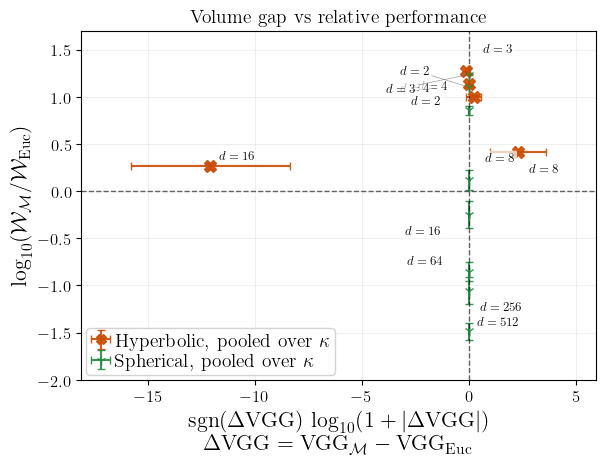

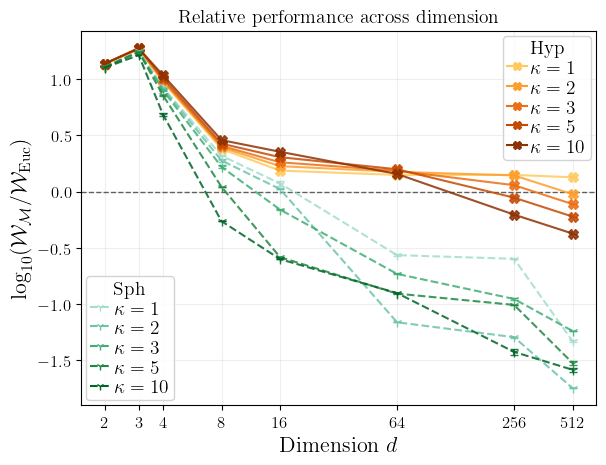

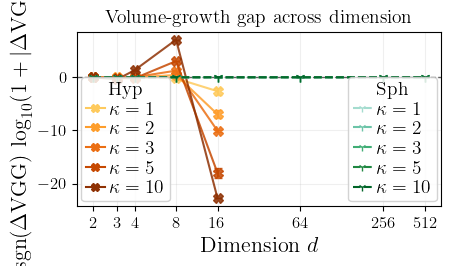

Manifold,Dimension,Poincaré vs Euclidean,Sphere vs Euclidean
0,2,"14× worse [14, 14]","13× worse [13, 13]"
1,3,"19× worse [19, 19]","17× worse [17, 17]"
2,4,"9.9× worse [9.7, 10]","7.4× worse [7, 7.8]"
3,8,"2.6× worse [2.5, 2.7]","1.3× worse [1.1, 1.5]"
4,16,"1.8× worse [1.8, 1.9]","0.56× better [0.47, 0.67]"
5,64,"1.5× worse [1.5, 1.5]","0.14× better [0.12, 0.16]"
6,256,"1× worse [0.96, 1.1]","0.088× better [0.074, 0.11]"
7,512,"0.76× better [0.68, 0.84]","0.033× better [0.029, 0.037]"


In [10]:
metrics_gtg_prep = prepare_rq1_dataframe(metrics_gtg)
summary_by_curvature_gtg = summarize_for_curvature_plot(metrics_gtg_prep)
metrics_gr_prep = prepare_rq1_dataframe(metrics_gaussian_ring)
summary_by_curvature_gr = summarize_for_curvature_plot(metrics_gr_prep)
metrics_mog_prep = prepare_rq1_dataframe(metrics_mog)
summary_by_curvature_mog = summarize_for_curvature_plot(metrics_mog_prep)
metrics_check_prep = prepare_rq1_dataframe(metrics_checkerboard)
summary_by_curvature_check = summarize_for_curvature_plot(metrics_check_prep)
metrics_gtg_norm_prep = prepare_rq1_dataframe(metrics_gtg_norm)
summary_by_curvature_gtg_norm = summarize_for_curvature_plot(metrics_gtg_norm_prep)


fig_a, ax_a, panel_a_df = plot_rq1_volume_gap_vs_performance(
    summary_by_curvature_gtg,
    legend_loc="lower left",
)
plt.show()

fig_b, ax_b = plot_rq1_dimension_vs_performance(
    summary_by_curvature_gtg,
    hyp_legend_loc="upper right",
    sph_legend_loc="lower left",
)
plt.show()

fig_c, ax_c = plot_rq1_dimension_vs_vgg(
    summary_by_curvature_gtg,
    hyp_legend_loc="lower left",
    sph_legend_loc="lower right",
)
plt.show()

main_story_table, main_story_long = make_main_data_story_table(metrics_gtg_prep)
display(main_story_table)

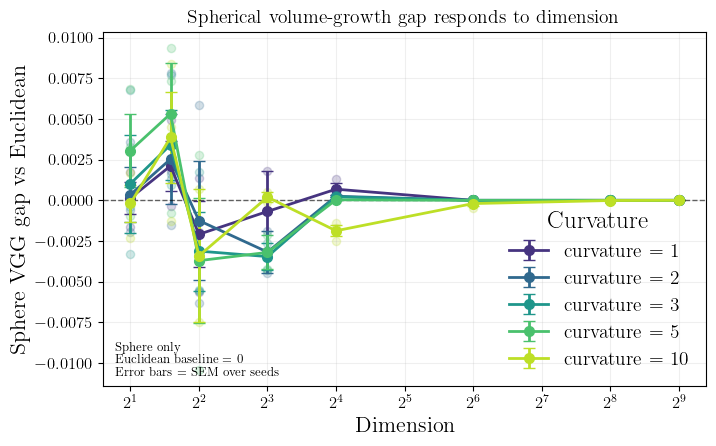

In [16]:
def plot_sphere_vgg_by_curvature(df_prepared, use_signed_log=False):
    """
    Sphere-only plot of VGG vs dimension, with separate lines per curvature.

    Shows:
    - faint points = individual seeds/runs
    - line + markers = mean per dimension/curvature
    - error bars = SEM over seeds
    """

    sphere_df = df_prepared[
        df_prepared[MANIFOLD_COL].eq(SPHERE_NAME)
    ].copy()

    sphere_df = sphere_df.replace([np.inf, -np.inf], np.nan)

    if use_signed_log:
        y_col = "signed_log_vgg_gap"
        y_label = "sgn(ΔVGG) · log10(1 + |ΔVGG|)"
        title = "Spherical volume-growth gap responds to dimension"
    else:
        y_col = "vgg_gap_vs_euc"
        y_label = "Sphere VGG gap vs Euclidean"
        title = "Spherical volume-growth gap responds to dimension"

    sphere_df = sphere_df.dropna(subset=["compare_dim", CURV_COL, y_col])

    summary = (
        sphere_df
        .groupby(["compare_dim", CURV_COL], as_index=False)
        .agg(
            y_mean=(y_col, "mean"),
            y_std=(y_col, "std"),
            y_n=(y_col, "count"),
        )
    )

    summary["y_sem"] = summary["y_std"] / np.sqrt(summary["y_n"])
    summary["y_sem"] = summary["y_sem"].fillna(0.0)
    summary = summary.sort_values(["curvature", "compare_dim"])

    curvatures = sorted(summary[CURV_COL].dropna().unique())

    cmap = plt.cm.viridis
    color_values = np.linspace(0.15, 0.9, len(curvatures))
    curvature_colors = {
        c: cmap(color_values[i])
        for i, c in enumerate(curvatures)
    }

    fig, ax = plt.subplots(figsize=(7.5, 4.8))

    for curvature in curvatures:
        raw_sub = sphere_df[sphere_df[CURV_COL].eq(curvature)]
        sum_sub = summary[summary[CURV_COL].eq(curvature)]

        color = curvature_colors[curvature]

        # Individual seeds/runs
        ax.scatter(
            raw_sub["compare_dim"],
            raw_sub[y_col],
            color=color,
            alpha=0.22,
            s=35,
        )

        # Mean ± SEM line
        ax.errorbar(
            sum_sub["compare_dim"],
            sum_sub["y_mean"],
            yerr=sum_sub["y_sem"],
            fmt="o-",
            color=color,
            markersize=7,
            capsize=4,
            linewidth=2,
            label=f"curvature = {nice_curv_label(curvature)}",
        )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    ax.set_xscale("log", base=2)

    ax.set_xlabel("Dimension")
    ax.set_ylabel(y_label)
    ax.set_title(title)

    ax.text(
        0.02,
        0.02,
        "Sphere only\nEuclidean baseline = 0\nError bars = SEM over seeds",
        transform=ax.transAxes,
        fontsize=9,
        va="bottom",
        ha="left",
    )

    ax.grid(alpha=0.2)
    ax.legend(frameon=False, title="Curvature")

    fig.tight_layout()

    return fig, ax, summary

fig, ax, summary = plot_sphere_vgg_by_curvature(metrics_gtg_prep, use_signed_log=False)

**Appendix**

In [11]:
# ============================================================
# Extra metric columns
# ============================================================

FRECHET_VAR_COL = "test_sample/frechet_variance_pred"
FRECHET_VAR_TARGET_COL = "test_sample/frechet_variance_target"
FRECHET_VAR_RATIO_COL = "test_sample/frechet_variance_ratio"

RADIUS_COL = "radius_x1"


# ============================================================
# General helpers
# ============================================================

def ordered_values_numeric(values, use_abs=False):
    values = pd.Series(values).dropna().unique()

    def sort_key(x):
        try:
            x = float(x)
            if use_abs:
                return (abs(x), x)
            return (x,)
        except Exception:
            return (str(x),)

    return sorted(values, key=sort_key)


def safe_log10(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.log10(x.where(x > 0))


def mean_sem(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()

    if len(x) == 0:
        return np.nan, np.nan, 0

    mean = x.mean()

    if len(x) == 1:
        return mean, 0.0, 1

    sem = x.std(ddof=1) / np.sqrt(len(x))
    return mean, sem, len(x)


def add_relative_to_euclidean(df_prepared, metric_col, out_col):
    """
    Adds metric / Euclidean metric at the same comparable dimension.

    Useful for Wasserstein and Fréchet variance if you want a fair
    comparison across dimension.
    """

    df = df_prepared.copy()

    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(euc_metric=(metric_col, "mean"))
    )

    df = df.merge(euc, on="compare_dim", how="left")
    df[out_col] = df[metric_col] / df["euc_metric"]

    return df

In [12]:
def make_curvature_dimension_surface(
    df_prepared,
    metric_col,
    value_col_name="value",
    relative_to_euclidean=False,
    log10_value=False,
    signed_log_value=False,
    exclude_euclidean=True,
):
    """
    Creates a summarized dataframe for heatmaps.

    Each cell is:
        mean metric over seeds
        for a given manifold × curvature × dimension.

    Options:
    - relative_to_euclidean:
        metric / Euclidean metric at same dimension
    - log10_value:
        log10 of the plotted value
    - signed_log_value:
        sign(x) * log10(1 + |x|)
    """

    df = df_prepared.copy()

    df[metric_col] = pd.to_numeric(df[metric_col], errors="coerce")

    if relative_to_euclidean:
        rel_col = f"{metric_col}_relative_to_euclidean"
        df = add_relative_to_euclidean(df, metric_col, rel_col)
        base_col = rel_col
    else:
        base_col = metric_col

    if log10_value:
        df[value_col_name] = safe_log10(df[base_col])
    elif signed_log_value:
        df[value_col_name] = signed_log1p(df[base_col])
    else:
        df[value_col_name] = df[base_col]

    if exclude_euclidean:
        df = df[~df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()

    rows = []

    for keys, sub in df.groupby([MANIFOLD_COL, CURV_COL, "compare_dim"], dropna=False):
        manifold, curvature, dim = keys

        mean, sem, n = mean_sem(sub[value_col_name])

        rows.append({
            MANIFOLD_COL: manifold,
            CURV_COL: curvature,
            "compare_dim": dim,
            "mean": mean,
            "sem": sem,
            "n": n,
        })

    return pd.DataFrame(rows)


def plot_curvature_dimension_heatmaps(
    surface_df,
    title,
    cbar_label,
    manifolds=(POINCARE_NAME, SPHERE_NAME),
    annotate=True,
    cmap="viridis",
    curvature_order_abs=True,
):
    """
    Plots one heatmap per manifold.

    x-axis: dimension
    y-axis: curvature
    color: metric surface value
    """

    manifolds = [m for m in manifolds if m in surface_df[MANIFOLD_COL].unique()]

    fig, axes = plt.subplots(
        1,
        len(manifolds),
        figsize=(6.2 * len(manifolds), 4.8),
        squeeze=False,
    )

    axes = axes[0]

    # Shared color scale across manifolds
    values = surface_df["mean"].replace([np.inf, -np.inf], np.nan)
    vmin = values.min()
    vmax = values.max()

    for ax, manifold in zip(axes, manifolds):
        sub = surface_df[surface_df[MANIFOLD_COL].eq(manifold)].copy()

        dims = ordered_values_numeric(sub["compare_dim"])
        curvatures = ordered_values_numeric(
            sub[CURV_COL],
            use_abs=curvature_order_abs,
        )

        pivot = (
            sub.pivot_table(
                index=CURV_COL,
                columns="compare_dim",
                values="mean",
                aggfunc="mean",
            )
            .reindex(index=curvatures, columns=dims)
        )

        im = ax.imshow(
            pivot.values,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation="gaussian",
        )

        ax.set_title(display_manifold_name(manifold))
        ax.set_xlabel("Dimension")
        ax.set_ylabel("Curvature")

        ax.set_xticks(np.arange(len(dims)))
        ax.set_xticklabels([nice_dim_label(d) for d in dims], rotation=45)

        ax.set_yticks(np.arange(len(curvatures)))
        ax.set_yticklabels([nice_curv_label(c) for c in curvatures])

        if annotate:
            for i in range(len(curvatures)):
                for j in range(len(dims)):
                    val = pivot.values[i, j]
                    if pd.notna(val):
                        ax.text(
                            j,
                            i,
                            f"{val:.2g}",
                            ha="center",
                            va="center",
                            fontsize=8,
                        )

    fig.suptitle(title, fontsize=15, y=1.04)

    cbar = fig.colorbar(im, ax=axes, shrink=0.85)
    cbar.set_label(cbar_label)


    return fig, axes

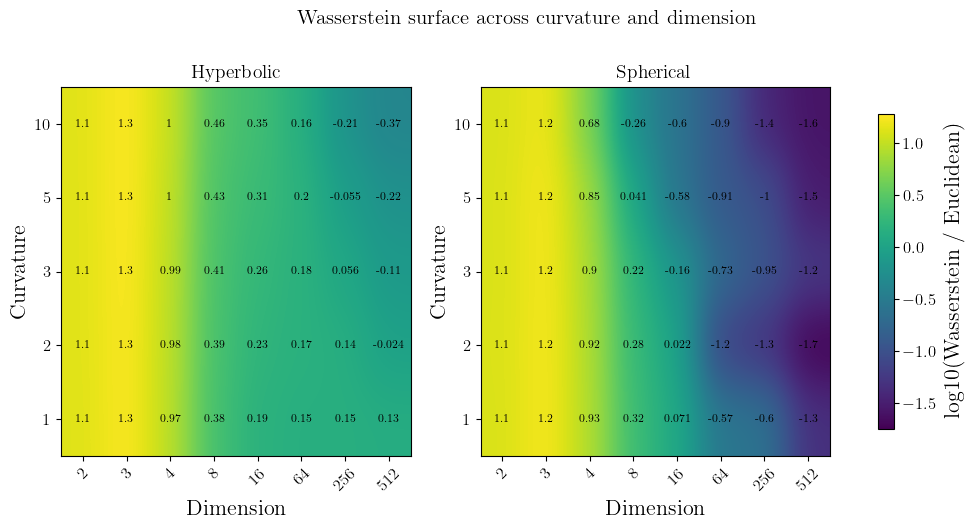

In [19]:
def plot_wasserstein_heatmaps(df_prepared):
    surface = make_curvature_dimension_surface(
        df_prepared,
        metric_col=PERF_COL,
        value_col_name="log_rel_wasserstein",
        relative_to_euclidean=True,
        log10_value=True,
    )

    fig, axes = plot_curvature_dimension_heatmaps(
        surface,
        title="Wasserstein surface across curvature and dimension",
        cbar_label="log10(Wasserstein / Euclidean)",
        annotate=True,
    )

    return fig, axes, surface


fig_wass, axes_wass, wasserstein_surface = plot_wasserstein_heatmaps(metrics_gtg_prep)
plt.show()

# Optional:
# fig_wass.savefig("rq1_heatmap_wasserstein_surface.png", dpi=300, bbox_inches="tight")
# wasserstein_surface.to_csv("rq1_heatmap_wasserstein_surface.csv", index=False)

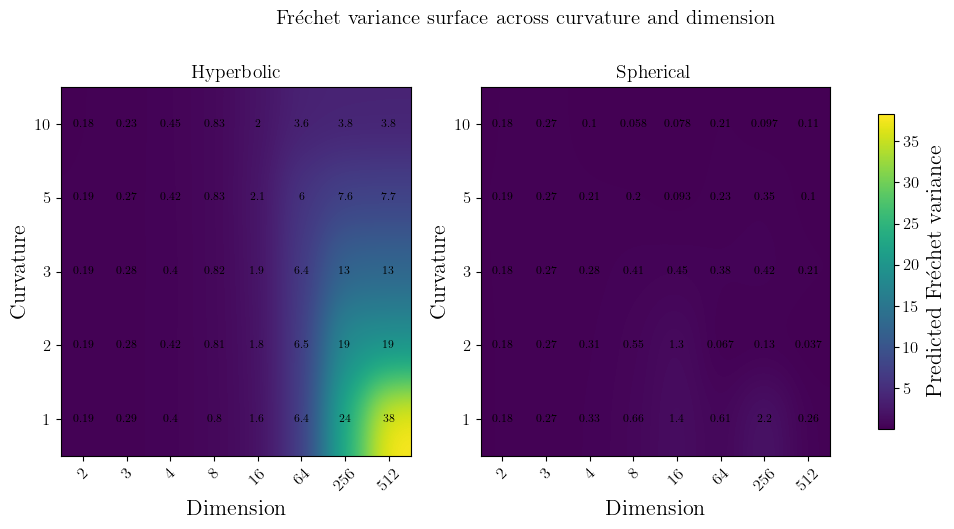

In [13]:
def plot_frechet_variance_heatmaps(df_prepared, relative_to_euclidean=False):
    surface = make_curvature_dimension_surface(
        df_prepared,
        metric_col=FRECHET_VAR_COL,
        value_col_name="frechet_variance_surface",
        relative_to_euclidean=relative_to_euclidean,
        log10_value=relative_to_euclidean,
    )

    if relative_to_euclidean:
        cbar_label = "log10(Fréchet variance / Euclidean)"
        title = "Relative Fréchet variance surface across curvature and dimension"
    else:
        cbar_label = "Predicted Fréchet variance"
        title = "Fréchet variance surface across curvature and dimension"

    fig, axes = plot_curvature_dimension_heatmaps(
        surface,
        title=title,
        cbar_label=cbar_label,
        annotate=True,
    )

    return fig, axes, surface


fig_fvar, axes_fvar, frechet_variance_surface = plot_frechet_variance_heatmaps(
    metrics_gtg_prep,
    relative_to_euclidean=False,
)

plt.show()

# Optional:
# fig_fvar.savefig("rq1_heatmap_frechet_variance_surface.png", dpi=300, bbox_inches="tight")

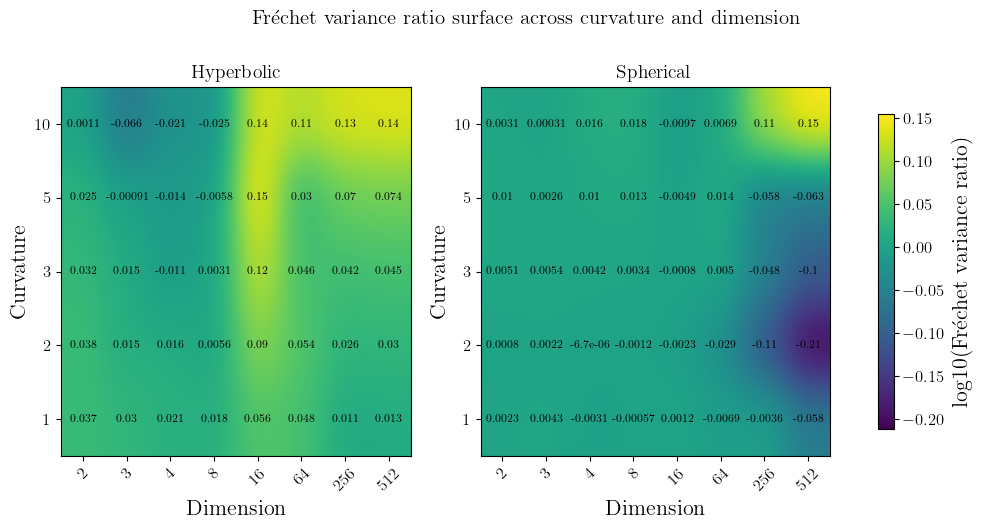

In [21]:
def plot_frechet_variance_ratio_heatmaps(df_prepared, log10_ratio=True):
    surface = make_curvature_dimension_surface(
        df_prepared,
        metric_col=FRECHET_VAR_RATIO_COL,
        value_col_name="frechet_variance_ratio_surface",
        relative_to_euclidean=False,
        log10_value=log10_ratio,
    )

    if log10_ratio:
        cbar_label = "log10(Fréchet variance ratio)"
        title = "Fréchet variance ratio surface across curvature and dimension"
    else:
        cbar_label = "Fréchet variance ratio"
        title = "Fréchet variance ratio surface across curvature and dimension"

    fig, axes = plot_curvature_dimension_heatmaps(
        surface,
        title=title,
        cbar_label=cbar_label,
        annotate=True,
    )

    return fig, axes, surface


fig_fvar_ratio, axes_fvar_ratio, frechet_variance_ratio_surface = (
    plot_frechet_variance_ratio_heatmaps(
        metrics_gtg_prep,
        log10_ratio=True,
    )
)

plt.show()

# Optional:
# fig_fvar_ratio.savefig("rq1_heatmap_frechet_variance_ratio_surface.png", dpi=300, bbox_inches="tight")

In [22]:
def make_spearman_vgg_wasserstein_table(df_prepared):
    """
    Spearman correlations between VGG and Wasserstein.

    Uses experiment means:
        dimension × manifold × curvature

    Reports both:
    - raw VGG vs raw Wasserstein
    - signed-log VGG vs log-relative Wasserstein
    """

    plot_df = df_prepared[
        ~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)
    ].copy()

    grouped = (
        plot_df
        .groupby(["compare_dim", MANIFOLD_COL, CURV_COL], as_index=False)
        .agg(
            wasserstein=(PERF_COL, "mean"),
            log_rel_wasserstein=("log_rel_perf", "mean"),
            vgg=("vgg_gap_vs_euc", "mean"),
            signed_log_vgg=("signed_log_vgg_gap", "mean"),
            n_seeds=(PERF_COL, "count"),
        )
    )

    rows = []

    subsets = [("All non-Euclidean", grouped)]

    for manifold in ordered_manifolds(grouped[MANIFOLD_COL]):
        sub = grouped[grouped[MANIFOLD_COL].eq(manifold)]
        subsets.append((display_manifold_name(manifold), sub))

    for label, sub in subsets:
        sub = sub.replace([np.inf, -np.inf], np.nan)

        raw = sub[["vgg", "wasserstein"]].dropna()
        transformed = sub[["signed_log_vgg", "log_rel_wasserstein"]].dropna()

        raw_rho = (
            raw["vgg"].corr(raw["wasserstein"], method="spearman")
            if len(raw) >= 3 else np.nan
        )

        transformed_rho = (
            transformed["signed_log_vgg"].corr(
                transformed["log_rel_wasserstein"],
                method="spearman",
            )
            if len(transformed) >= 3 else np.nan
        )

        rows.append({
            "Subset": label,
            "n experiments": len(sub),
            "Spearman rho: raw VGG vs raw Wasserstein": raw_rho,
            "Spearman rho: signed-log VGG vs log-relative Wasserstein": transformed_rho,
        })

    table = pd.DataFrame(rows)

    return table, grouped


spearman_table, spearman_experiment_means = make_spearman_vgg_wasserstein_table(
    metrics_gtg_prep
)

display(spearman_table)

# Optional:
# spearman_table.to_csv("rq1_spearman_vgg_wasserstein_table.csv", index=False)
# spearman_experiment_means.to_csv("rq1_spearman_experiment_means.csv", index=False)

,Subset,n experiments,Spearman rho: raw VGG vs raw Wasserstein,Spearman rho: signed-log VGG vs log-relative Wasserstein
0,All non-Euclidean,80,-0.103170,-0.112505
1,Hyperbolic,40,-0.304615,0.236154
2,Spherical,40,-0.127586,0.313567


In [23]:
def plot_gaussian_ring_radius_vgg_wasserstein(
    ring_df,
    use_log_relative_wasserstein=True,
    manifold=None,
):
    """
    Appendix plot for Gaussian ring experiments.

    Panel A:
        radius vs VGG

    Panel B:
        radius vs Wasserstein

    Lines are drawn separately for each manifold × dimension × curvature.
    """

    if manifold is not None:
        ring_df = ring_df[ring_df[MANIFOLD_COL].eq(manifold)].copy()

    if ring_df.empty:
        print("No rows left after filtering.")
        return None, None, pd.DataFrame()

    y_wass_col = np.log(ring_df[PERF_COL]) if use_log_relative_wasserstein else PERF_COL

    grouped = (
        ring_df
        .groupby([MANIFOLD_COL, "dim", CURV_COL, RADIUS_COL], as_index=False)
        .agg(
            vgg_mean=("test_sample/volume_scaling_gap_target_minus_pred", "mean"),
            vgg_sem=("test_sample/volume_scaling_gap_target_minus_pred", lambda x: mean_sem(x)[1]),
            wass_mean=(y_wass_col, "mean"),
            wass_sem=(y_wass_col, lambda x: mean_sem(x)[1]),
            n=(PERF_COL, "count"),
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    manifolds = ordered_manifolds(grouped[MANIFOLD_COL])
    dims = ordered_values_numeric(grouped["dim"])
    curvatures = ordered_values_numeric(grouped[CURV_COL], use_abs=True)

    cmap = plt.cm.viridis
    color_positions = np.linspace(0.15, 0.9, max(len(dims), 1))
    dim_colors = {
        d: cmap(color_positions[i])
        for i, d in enumerate(dims)
    }

    marker_map = {
        POINCARE_NAME: "o",
        SPHERE_NAME: "s",
    }

    line_map = {
        POINCARE_NAME: "solid",
        SPHERE_NAME: "dashed",
    }

    for manifold_name in manifolds:
        for dim in dims:
            for curvature in curvatures:
                sub = grouped[
                    grouped[MANIFOLD_COL].eq(manifold_name)
                    & grouped["dim"].eq(dim)
                    & grouped[CURV_COL].eq(curvature)
                ].sort_values(RADIUS_COL)

                if sub.empty:
                    continue

                label = (
                    f"{display_manifold_name(manifold_name)}, "
                    f"d={nice_dim_label(dim)}, "
                    f"c={nice_curv_label(curvature)}"
                )

                color = dim_colors[dim]
                marker = marker_map.get(manifold_name, "o")
                linestyle = line_map.get(manifold_name, "solid")

                axes[0].errorbar(
                    sub[RADIUS_COL],
                    sub["vgg_mean"],
                    yerr=sub["vgg_sem"],
                    fmt=marker,
                    linestyle=linestyle,
                    color=color,
                    capsize=3,
                    alpha=0.85,
                    label=label,
                )

                axes[1].errorbar(
                    sub[RADIUS_COL],
                    sub["wass_mean"],
                    yerr=sub["wass_sem"],
                    fmt=marker,
                    linestyle=linestyle,
                    color=color,
                    capsize=3,
                    alpha=0.85,
                )

    axes[0].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)

    axes[0].set_title("A. Radius vs volume-growth gap")
    axes[0].set_xlabel("Gaussian ring radius")
    axes[0].set_ylabel("sgn(ΔVGG) · log10(1 + |ΔVGG|)")

    axes[1].set_title("B. Radius vs Wasserstein performance")
    axes[1].set_xlabel("Gaussian ring radius")

    if use_log_relative_wasserstein:
        axes[1].set_ylabel("log10(Wasserstein / Euclidean)")
    else:
        axes[1].set_ylabel("Wasserstein")

    for ax in axes:
        ax.grid(alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        fontsize=8,
    )

    fig.suptitle("Gaussian ring: radius dependence of VGG and RFM performance", y=1.03)
    fig.tight_layout()

    return fig, axes, grouped

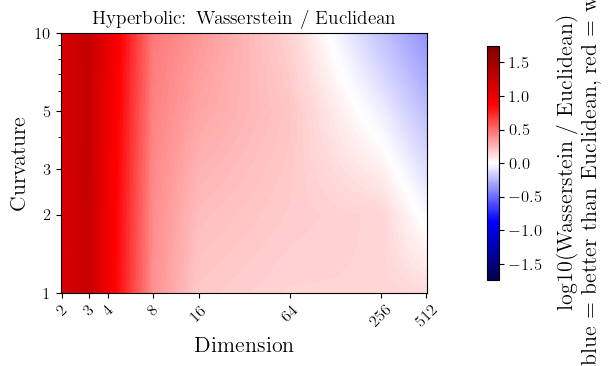

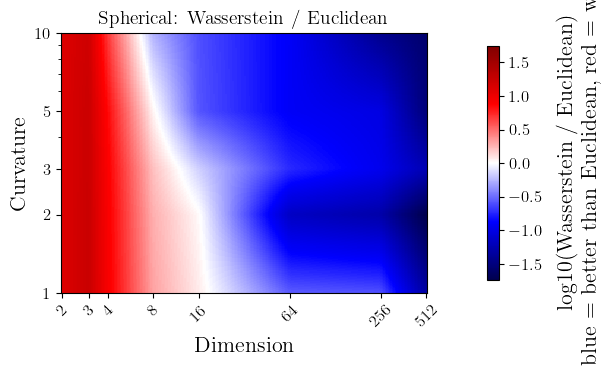

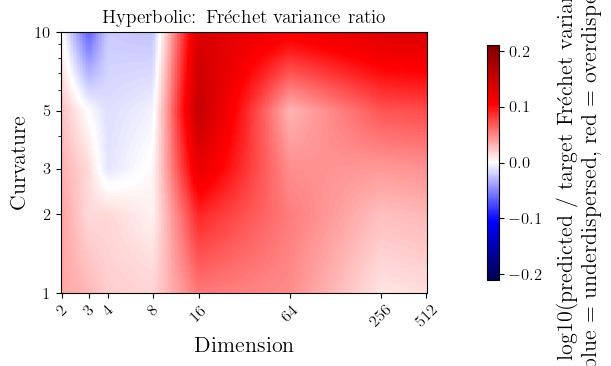

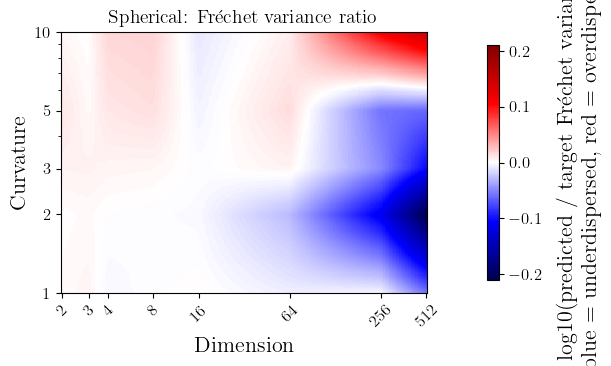

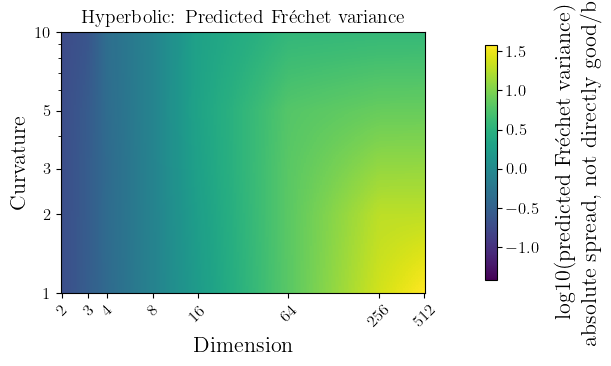

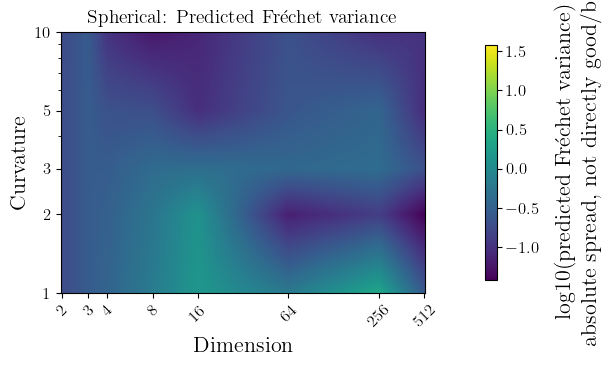

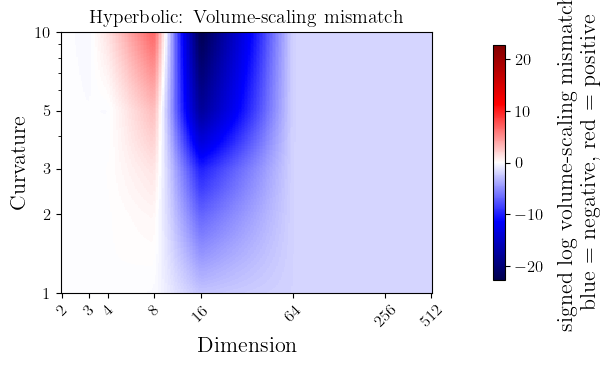

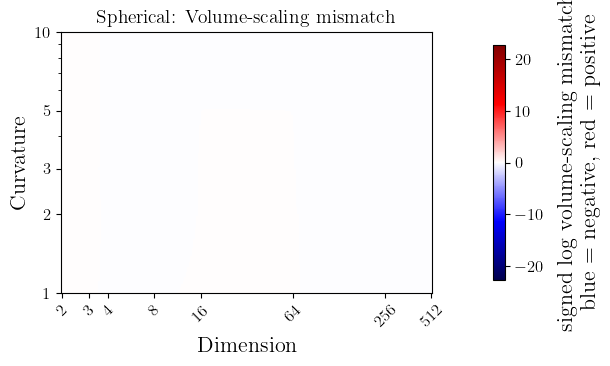

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from matplotlib.colors import TwoSlopeNorm


def plot_single_metric_heatmap_logscaled(
    surface_df,
    manifold,
    title,
    cbar_label,
    cmap="seismic",
    smooth=True,
    smoothing_sigma=1.2,
    dense_n=250,
    curvature_order_abs=True,
    center_zero=True,
    shared_absmax=None,
):
    def smooth_on_log_grid(dims, curvatures, values):
        dims = np.asarray(dims, dtype=float)
        curvatures = np.asarray(curvatures, dtype=float)

        x = np.log2(dims)
        y = np.log(curvatures)

        filled = values.astype(float).copy()
        if np.isnan(filled).any():
            filled = np.where(np.isnan(filled), np.nanmean(filled), filled)

        interpolator = RegularGridInterpolator(
            (y, x),
            filled,
            bounds_error=False,
            fill_value=None,
        )

        x_dense = np.linspace(x.min(), x.max(), dense_n)
        y_dense = np.linspace(y.min(), y.max(), dense_n)

        xx_dense, yy_dense = np.meshgrid(x_dense, y_dense)
        points = np.column_stack([yy_dense.ravel(), xx_dense.ravel()])

        zz_dense = interpolator(points).reshape(dense_n, dense_n)

        if smooth:
            zz_dense = gaussian_filter(zz_dense, sigma=smoothing_sigma)

        dims_dense = 2 ** x_dense
        curv_dense = np.exp(y_dense)

        return dims_dense, curv_dense, zz_dense

    sub = surface_df[surface_df[MANIFOLD_COL].eq(manifold)].copy()

    dims = ordered_values_numeric(sub["compare_dim"])
    curvatures = ordered_values_numeric(
        sub[CURV_COL],
        use_abs=curvature_order_abs,
    )

    pivot = (
        sub.pivot_table(
            index=CURV_COL,
            columns="compare_dim",
            values="mean",
            aggfunc="mean",
        )
        .reindex(index=curvatures, columns=dims)
    )

    dims_arr = np.asarray(dims, dtype=float)
    curv_arr = np.asarray(curvatures, dtype=float)

    dims_dense, curv_dense, plot_values = smooth_on_log_grid(
        dims_arr,
        curv_arr,
        pivot.values,
    )

    fig, ax = plt.subplots(figsize=(4 * 1.618, 4))

    if center_zero:
        if shared_absmax is None:
            values = surface_df["mean"].replace([np.inf, -np.inf], np.nan).to_numpy()
            shared_absmax = np.nanmax(np.abs(values))

        norm = TwoSlopeNorm(
            vmin=-shared_absmax,
            vcenter=0.0,
            vmax=shared_absmax,
        )

        mesh = ax.pcolormesh(
            dims_dense,
            curv_dense,
            plot_values,
            shading="auto",
            cmap=cmap,
            norm=norm,
        )
    else:
        values = surface_df["mean"].replace([np.inf, -np.inf], np.nan).to_numpy()

        mesh = ax.pcolormesh(
            dims_dense,
            curv_dense,
            plot_values,
            shading="auto",
            cmap=cmap,
            vmin=np.nanmin(values),
            vmax=np.nanmax(values),
        )

    ax.set_xscale("log", base=2)
    ax.set_yscale("log")

    ax.set_title(title)
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Curvature")

    ax.set_xticks(dims_arr)
    ax.set_xticklabels([nice_dim_label(d) for d in dims_arr], rotation=45)

    ax.set_yticks(curv_arr)
    ax.set_yticklabels([nice_curv_label(c) for c in curv_arr])

    cbar = fig.colorbar(mesh, ax=ax, pad=0.12, shrink=0.9)
    cbar.set_label(cbar_label, labelpad=10)

    fig.tight_layout()
    plt.show()

    return fig, ax


def make_and_plot_metric_heatmaps(
    df_prepared,
    metric_col,
    value_col_name,
    title_base,
    cbar_label,
    relative_to_euclidean=False,
    log10_value=False,
    signed_log_value=False,
    cmap="seismic",
    center_zero=True,
    smooth=True,
):
    surface = make_curvature_dimension_surface(
        df_prepared,
        metric_col=metric_col,
        value_col_name=value_col_name,
        relative_to_euclidean=relative_to_euclidean,
        log10_value=log10_value,
        signed_log_value=signed_log_value,
    )

    values = surface["mean"].replace([np.inf, -np.inf], np.nan).to_numpy()
    shared_absmax = np.nanmax(np.abs(values)) if center_zero else None

    fig_hyp, ax_hyp = plot_single_metric_heatmap_logscaled(
        surface_df=surface,
        manifold=POINCARE_NAME,
        title=f"Hyperbolic: {title_base}",
        cbar_label=cbar_label,
        cmap=cmap,
        center_zero=center_zero,
        shared_absmax=shared_absmax,
        smooth=smooth,
    )

    fig_sph, ax_sph = plot_single_metric_heatmap_logscaled(
        surface_df=surface,
        manifold=SPHERE_NAME,
        title=f"Spherical: {title_base}",
        cbar_label=cbar_label,
        cmap=cmap,
        center_zero=center_zero,
        shared_absmax=shared_absmax,
        smooth=smooth,
    )

    return surface, (fig_hyp, ax_hyp), (fig_sph, ax_sph)


wasserstein_surface, _, _ = make_and_plot_metric_heatmaps(
    metrics_gtg_prep,
    metric_col=PERF_COL,
    value_col_name="log_rel_wasserstein",
    title_base="Wasserstein / Euclidean",
    cbar_label="log10(Wasserstein / Euclidean)\nblue = better than Euclidean, red = worse",
    relative_to_euclidean=True,
    log10_value=True,
    cmap="seismic",
    center_zero=True,
    smooth=True,
)

frechet_variance_ratio_surface, _, _ = make_and_plot_metric_heatmaps(
    metrics_gtg_prep,
    metric_col=FRECHET_VAR_RATIO_COL,
    value_col_name="log_frechet_variance_ratio",
    title_base="Fréchet variance ratio",
    cbar_label="log10(predicted / target Fréchet variance)\nblue = underdispersed, red = overdispersed",
    relative_to_euclidean=False,
    log10_value=True,
    cmap="seismic",
    center_zero=True,
    smooth=True,
)

frechet_variance_surface, _, _ = make_and_plot_metric_heatmaps(
    metrics_gtg_prep,
    metric_col=FRECHET_VAR_COL,
    value_col_name="log_frechet_variance",
    title_base="Predicted Fréchet variance",
    cbar_label="log10(predicted Fréchet variance)\nabsolute spread, not directly good/bad",
    relative_to_euclidean=False,
    log10_value=True,
    cmap="viridis",
    center_zero=False,
    smooth=True,
)

vgg_surface, _, _ = make_and_plot_metric_heatmaps(
    metrics_gtg_prep,
    metric_col=VGG_COL,
    value_col_name="signed_log_vgg",
    title_base="Volume-scaling mismatch",
    cbar_label="signed log volume-scaling mismatch\nblue = negative, red = positive",
    relative_to_euclidean=False,
    signed_log_value=True,
    cmap="seismic",
    center_zero=True,
    smooth=True,
)

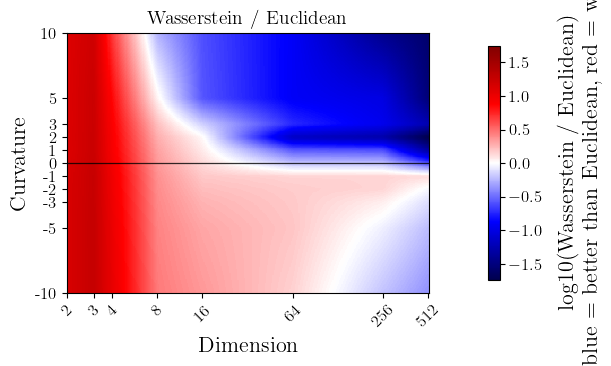

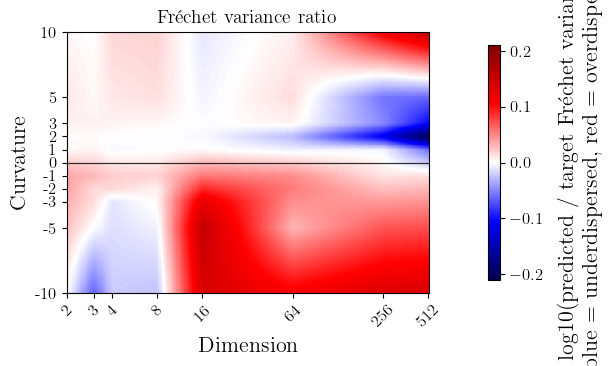

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from matplotlib.colors import TwoSlopeNorm


def plot_signed_curvature_metric_heatmap_continuous(
    surface_df,
    title,
    cbar_label,
    cmap="seismic",
    center_zero=True,
    smooth=True,
    smoothing_sigma=1.2,
    dense_nx=320,
    dense_ny=320,
    figsize=(4 * 1.618, 4),
):
    def signed_curvature_from_row(row):
        manifold = str(row[MANIFOLD_COL]).lower()
        curv = float(row[CURV_COL])

        if manifold in [str(POINCARE_NAME).lower(), "poincare", "hyperbolic"]:
            return -abs(curv)
        if manifold in [str(SPHERE_NAME).lower(), "sphere", "spherical"]:
            return abs(curv)
        return 0.0

    df = surface_df.copy()
    df["signed_curvature"] = df.apply(signed_curvature_from_row, axis=1)
    df["compare_dim"] = pd.to_numeric(df["compare_dim"], errors="coerce")
    df["mean"] = pd.to_numeric(df["mean"], errors="coerce")

    dims = np.asarray(ordered_values_numeric(df["compare_dim"]), dtype=float)
    signed_curvs = np.asarray(sorted(df["signed_curvature"].unique()), dtype=float)

    pivot = (
        df.pivot_table(
            index="signed_curvature",
            columns="compare_dim",
            values="mean",
            aggfunc="mean",
        )
        .reindex(index=signed_curvs, columns=dims)
    )

    if 0.0 not in pivot.index:
        zero_vals = []
        neg_curvs = np.asarray([c for c in pivot.index if c < 0], dtype=float)
        pos_curvs = np.asarray([c for c in pivot.index if c > 0], dtype=float)

        neg_nearest = neg_curvs.max() if len(neg_curvs) else np.nan
        pos_nearest = pos_curvs.min() if len(pos_curvs) else np.nan

        for dim in dims:
            v_neg = pivot.loc[neg_nearest, dim] if pd.notna(neg_nearest) and neg_nearest in pivot.index else np.nan
            v_pos = pivot.loc[pos_nearest, dim] if pd.notna(pos_nearest) and pos_nearest in pivot.index else np.nan

            if pd.notna(v_neg) and pd.notna(v_pos):
                zero_vals.append(0.5 * (v_neg + v_pos))
            elif pd.notna(v_neg):
                zero_vals.append(v_neg)
            elif pd.notna(v_pos):
                zero_vals.append(v_pos)
            else:
                zero_vals.append(np.nan)

        pivot.loc[0.0] = zero_vals
        pivot = pivot.sort_index()

    pivot = pivot.interpolate(axis=0, limit_direction="both")
    pivot = pivot.interpolate(axis=1, limit_direction="both")

    x = np.log2(np.asarray(pivot.columns, dtype=float))
    y = np.asarray(pivot.index, dtype=float)
    z = pivot.values.astype(float)

    interpolator = RegularGridInterpolator(
        (y, x),
        z,
        bounds_error=False,
        fill_value=None,
    )

    x_dense = np.linspace(x.min(), x.max(), dense_nx)
    y_dense = np.linspace(y.min(), y.max(), dense_ny)

    xx_dense, yy_dense = np.meshgrid(x_dense, y_dense)
    pts = np.column_stack([yy_dense.ravel(), xx_dense.ravel()])
    zz_dense = interpolator(pts).reshape(dense_ny, dense_nx)

    if smooth:
        zz_dense = gaussian_filter(zz_dense, sigma=smoothing_sigma)

    dims_dense = 2 ** x_dense
    curv_dense = y_dense

    vals = pivot.values.astype(float)
    if center_zero:
        absmax = np.nanmax(np.abs(vals))
        norm = TwoSlopeNorm(vmin=-absmax, vcenter=0.0, vmax=absmax)
        vmin = vmax = None
    else:
        norm = None
        vmin = np.nanmin(vals)
        vmax = np.nanmax(vals)

    fig, ax = plt.subplots(figsize=figsize)

    mesh = ax.pcolormesh(
        dims_dense,
        curv_dense,
        zz_dense,
        shading="auto",
        cmap=cmap,
        norm=norm,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xscale("log", base=2)
    ax.set_yscale("linear")

    ax.set_xlabel("Dimension")
    ax.set_ylabel("Curvature")
    ax.set_title(title)

    ax.set_xticks(dims)
    ax.set_xticklabels([nice_dim_label(d) for d in dims], rotation=45)

    curv_ticks = np.array([-10, -5, -3, -2, -1, 0, 1, 2, 3, 5, 10], dtype=float)
    curv_ticks = curv_ticks[(curv_ticks >= curv_dense.min()) & (curv_ticks <= curv_dense.max())]
    ax.set_yticks(curv_ticks)
    ax.set_yticklabels([nice_curv_label(c) for c in curv_ticks])

    ax.axhline(0, color="black", linewidth=0.9, alpha=0.8)

    cbar = fig.colorbar(mesh, ax=ax, pad=0.12, shrink=0.9)
    cbar.set_label(cbar_label, labelpad=10)

    fig.tight_layout()
    plt.show()

    return fig, ax, pivot


# wasserstein / euclidean
wasserstein_surface = make_curvature_dimension_surface(
    metrics_gtg_prep,
    metric_col=PERF_COL,
    value_col_name="log_rel_wasserstein",
    relative_to_euclidean=True,
    log10_value=True,
    exclude_euclidean=True,
)

fig_w, ax_w, pivot_w = plot_signed_curvature_metric_heatmap_continuous(
    wasserstein_surface,
    title="Wasserstein / Euclidean",
    cbar_label="log10(Wasserstein / Euclidean)\nblue = better than Euclidean, red = worse",
    cmap="seismic",
    center_zero=True,
)


# fréchet variance ratio
frechet_variance_ratio_surface = make_curvature_dimension_surface(
    metrics_gtg_prep,
    metric_col=FRECHET_VAR_RATIO_COL,
    value_col_name="log_frechet_variance_ratio",
    relative_to_euclidean=False,
    log10_value=True,
    exclude_euclidean=True,
)

fig_fvr, ax_fvr, pivot_fvr = plot_signed_curvature_metric_heatmap_continuous(
    frechet_variance_ratio_surface,
    title="Fréchet variance ratio",
    cbar_label="log10(predicted / target Fréchet variance)\nblue = underdispersed, red = overdispersed",
    cmap="seismic",
    center_zero=True,
)

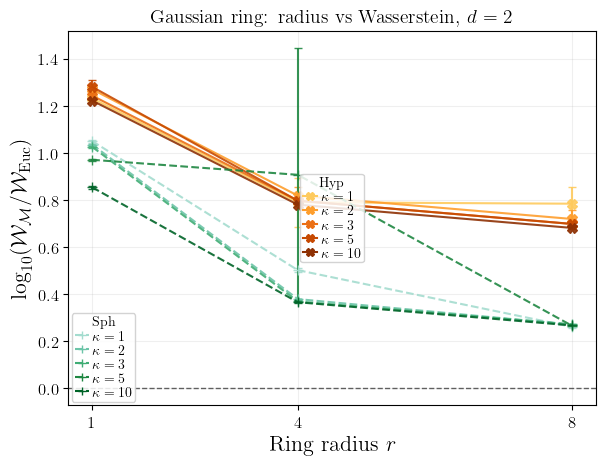

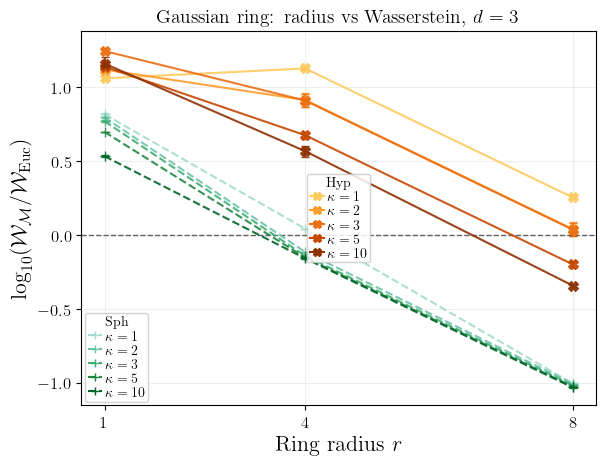

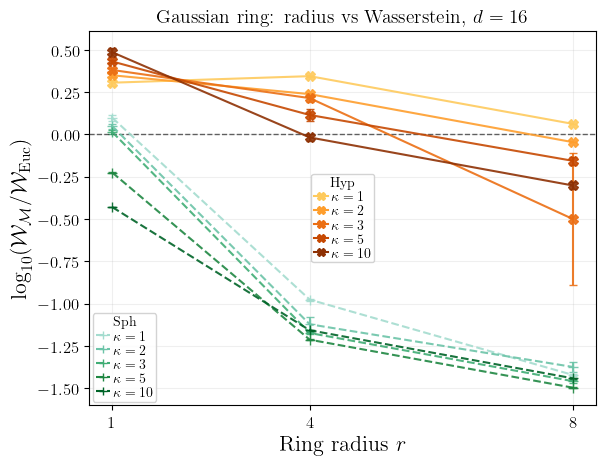

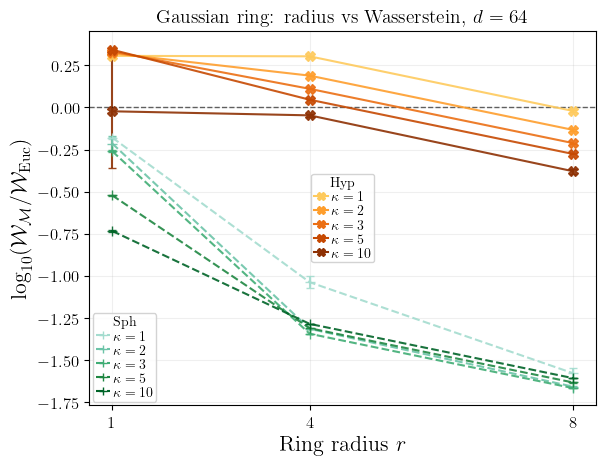

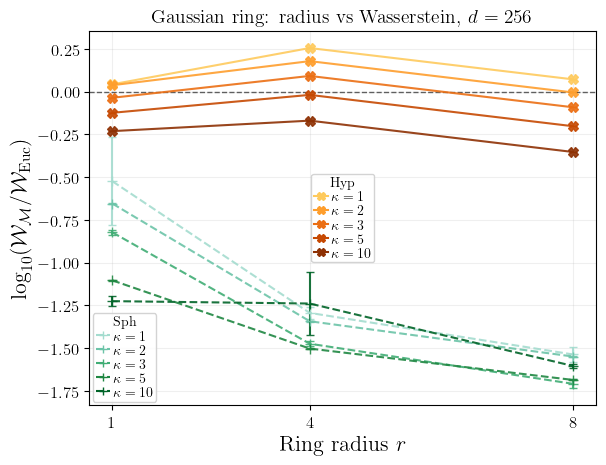

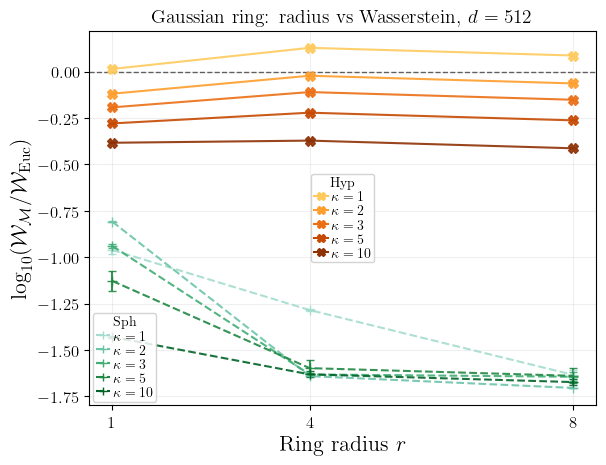

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl

# ============================================================
# User settings
# ============================================================

PERF_COL = "test_sample/sinkhorn_knopp"
VGG_COL = "test_sample/volume_scaling_gap_target_minus_pred"

DIM_COL = "dim"
MANIFOLD_COL = "manifold"
CURV_COL = "curvature"
RADIUS_COL = "radius_x1"

EUCLIDEAN_NAME = "euclidean"
POINCARE_NAME = "poincare"
SPHERE_NAME = "sphere"

SPHERE_DIM_MINUS_ONE = True

ERROR_BAR = "sem"        # "sem" or "std"
CURVATURE_ORDER = "abs"

LEGEND_FONTSIZE = 10
LEGEND_FRAME_ALPHA = 0.85


# ============================================================
# Helpers
# ============================================================

def signed_log1p(x):
    """Signed log transform: keeps sign, handles zero, compresses large values."""
    return np.sign(x) * np.log10(1 + np.abs(x))


def error_value(x, kind="sem"):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()

    if len(x) <= 1:
        return 0.0

    if kind == "std":
        return x.std(ddof=1)

    if kind == "sem":
        return x.std(ddof=1) / np.sqrt(len(x))

    return 0.0


def nice_dim_label(x):
    if pd.isna(x):
        return ""
    if float(x).is_integer():
        return str(int(x))
    return f"{x:g}"


def nice_curv_label(x):
    if pd.isna(x):
        return "NA"
    try:
        return f"{float(x):g}"
    except Exception:
        return str(x)


def display_manifold_name(m):
    if m == POINCARE_NAME:
        return "Hyperbolic"
    if m == SPHERE_NAME:
        return "Spherical"
    if m == EUCLIDEAN_NAME:
        return "Euclidean"
    return str(m)


def ordered_curvatures(values, order="abs"):
    values = pd.Series(values).dropna().unique()

    def sort_key(x):
        try:
            x_float = float(x)

            if order == "abs":
                return (abs(x_float), x_float)

            if order == "numeric":
                return (x_float,)

        except Exception:
            pass

        return (str(x),)

    return sorted(values, key=sort_key)


def ordered_manifolds(values):
    preferred_order = [POINCARE_NAME, SPHERE_NAME, EUCLIDEAN_NAME]
    values = list(pd.Series(values).dropna().unique())

    ordered = [m for m in preferred_order if m in values]
    ordered += [m for m in values if m not in ordered]

    return ordered


def add_grouped_curvature_legends(
    ax,
    specs,
    hyp_loc="upper right",
    sph_loc="center right",
    fontsize=LEGEND_FONTSIZE,
):
    """
    Adds two compact legends:
    one for Hyperbolic curvatures and one for Spherical curvatures.
    """

    hyp_handles, hyp_labels = [], []
    sph_handles, sph_labels = [], []

    for spec in specs:
        handle = plt.Line2D(
            [0],
            [0],
            color=spec["color"],
            marker=spec["marker"],
            linestyle=spec["linestyle"],
            linewidth=1.5,
            markersize=6,
        )

        label = rf"$\kappa={nice_curv_label(spec['curvature'])}$"

        if spec["manifold"] == POINCARE_NAME:
            hyp_handles.append(handle)
            hyp_labels.append(label)

        elif spec["manifold"] == SPHERE_NAME:
            sph_handles.append(handle)
            sph_labels.append(label)

    hyp_legend = None
    sph_legend = None

    if hyp_handles:
        hyp_legend = ax.legend(
            hyp_handles,
            hyp_labels,
            title=r"$\mathrm{Hyp}$",
            loc=hyp_loc,
            frameon=True,
            framealpha=LEGEND_FRAME_ALPHA,
            fontsize=fontsize,
            title_fontsize=fontsize,
            ncol=1,
            handlelength=1.0,
            handletextpad=0.25,
            labelspacing=0.12,
            borderpad=0.22,
            borderaxespad=0.25,
            markerscale=0.85,
        )
        ax.add_artist(hyp_legend)

    if sph_handles:
        sph_legend = ax.legend(
            sph_handles,
            sph_labels,
            title=r"$\mathrm{Sph}$",
            loc=sph_loc,
            frameon=True,
            framealpha=LEGEND_FRAME_ALPHA,
            fontsize=fontsize,
            title_fontsize=fontsize,
            ncol=1,
            handlelength=1.0,
            handletextpad=0.25,
            labelspacing=0.12,
            borderpad=0.22,
            borderaxespad=0.25,
            markerscale=0.85,
        )

    return hyp_legend, sph_legend


# ============================================================
# Data preparation
# ============================================================

def prepare_gaussian_ring_dataframe(df):
    """
    Adds:
    - compare_dim
    - Euclidean baselines per dimension and radius
    - log-relative Wasserstein wrt Euclidean
    - signed-log VGG gap wrt Euclidean
    """

    df = df.copy()

    # Keep only Gaussian-ring rows if the column exists
    if "x1_dist" in df.columns:
        df = df[
            df["x1_dist"].astype(str).str.lower().str.contains("ring", na=False)
        ].copy()

    for col in [PERF_COL, VGG_COL, DIM_COL, CURV_COL, RADIUS_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Comparable intrinsic dimension
    df["compare_dim"] = df[DIM_COL]

    if SPHERE_DIM_MINUS_ONE:
        is_sphere = df[MANIFOLD_COL].eq(SPHERE_NAME)
        df.loc[is_sphere, "compare_dim"] = df.loc[is_sphere, DIM_COL] - 1

    # Euclidean baseline at same dimension and same radius
    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby(["compare_dim", RADIUS_COL], as_index=False)
        .agg(
            euc_wasserstein=(PERF_COL, "mean"),
            euc_vgg=(VGG_COL, "mean"),
        )
    )

    euc["euc_vgg"] = euc["euc_vgg"].fillna(0.0)

    df = df.merge(
        euc,
        on=["compare_dim", RADIUS_COL],
        how="left",
    )

    # Relative Wasserstein performance
    df["rel_wasserstein"] = df[PERF_COL] / df["euc_wasserstein"]
    df["log_rel_wasserstein"] = np.log10(df["rel_wasserstein"])

    # VGG relative to Euclidean
    df["vgg_gap_vs_euc"] = df[VGG_COL] - df["euc_vgg"]
    df["signed_log_vgg_gap"] = signed_log1p(df["vgg_gap_vs_euc"])

    return df


def summarize_gaussian_ring_by_radius(df_ring):
    """
    Averages over seeds for each:
        dimension × manifold × curvature × radius
    """

    plot_df = df_ring[
        ~df_ring[MANIFOLD_COL].eq(EUCLIDEAN_NAME)
    ].copy()

    group_cols = ["compare_dim", MANIFOLD_COL, CURV_COL, RADIUS_COL]

    rows = []

    for keys, sub in plot_df.groupby(group_cols, dropna=False):
        compare_dim, manifold, curvature, radius = keys

        vgg = sub["signed_log_vgg_gap"].replace([np.inf, -np.inf], np.nan).dropna()
        wass = sub["log_rel_wasserstein"].replace([np.inf, -np.inf], np.nan).dropna()

        rows.append({
            "compare_dim": compare_dim,
            MANIFOLD_COL: manifold,
            CURV_COL: curvature,
            RADIUS_COL: radius,

            "vgg_mean": vgg.mean(),
            "vgg_err": error_value(vgg, ERROR_BAR),
            "vgg_n": len(vgg),

            "wass_mean": wass.mean(),
            "wass_err": error_value(wass, ERROR_BAR),
            "wass_n": len(wass),
        })

    return pd.DataFrame(rows)


# ============================================================
# Plot styling
# ============================================================

def get_ring_style_specs(summary_dim):
    marker_map = {
        POINCARE_NAME: "X",
        SPHERE_NAME: "+",
    }

    line_map = {
        POINCARE_NAME: "solid",
        SPHERE_NAME: "dashed",
    }

    manifold_cmap_map = {
        POINCARE_NAME: plt.cm.YlOrBr,
        SPHERE_NAME: plt.cm.BuGn,
    }

    manifolds = ordered_manifolds(summary_dim[MANIFOLD_COL])
    curvatures = ordered_curvatures(summary_dim[CURV_COL], order=CURVATURE_ORDER)

    curvature_color_map = {}

    for manifold in manifolds:
        manifold_curvatures = ordered_curvatures(
            summary_dim.loc[summary_dim[MANIFOLD_COL].eq(manifold), CURV_COL],
            order=CURVATURE_ORDER,
        )

        cmap = manifold_cmap_map.get(manifold, plt.cm.viridis)
        color_positions = np.linspace(0.35, 0.9, max(len(manifold_curvatures), 1))

        for i, curvature in enumerate(manifold_curvatures):
            curvature_color_map[(manifold, curvature)] = cmap(color_positions[i])

    specs = []

    for manifold in manifolds:
        for curvature in curvatures:
            sub = summary_dim[
                summary_dim[MANIFOLD_COL].eq(manifold)
                & summary_dim[CURV_COL].eq(curvature)
            ].copy()

            if sub.empty:
                continue

            specs.append({
                "sub": sub.sort_values(RADIUS_COL),
                "color": curvature_color_map.get((manifold, curvature), "C0"),
                "marker": marker_map.get(manifold, "o"),
                "linestyle": line_map.get(manifold, "solid"),
                "manifold": manifold,
                "curvature": curvature,
            })

    return specs


def get_ring_dimension_subset(ring_summary, compare_dim):
    summary_dim = ring_summary[
        ring_summary["compare_dim"].eq(compare_dim)
    ].copy()

    if summary_dim.empty:
        available_dims = sorted(ring_summary["compare_dim"].dropna().unique())
        raise ValueError(
            f"No data found for compare_dim={compare_dim}. "
            f"Available dimensions: {available_dims}"
        )

    return summary_dim


def format_radius_axis(ax, summary_dim):
    radii = sorted(summary_dim[RADIUS_COL].dropna().unique())
    ax.set_xticks(radii)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())


# ============================================================
# Plot 1: radius vs VGG
# ============================================================

def plot_gaussian_ring_radius_vgg(
    ring_summary,
    compare_dim,
    figsize=(6.4, 5.0),
    hyp_legend_loc="upper right",
    sph_legend_loc="center right",
):
    """
    Gaussian ring plot for one comparable dimension.

    x-axis:
        ring radius

    y-axis:
        signed-log VGG gap relative to Euclidean
    """

    summary_dim = get_ring_dimension_subset(ring_summary, compare_dim)
    specs = get_ring_style_specs(summary_dim)

    fig, ax = plt.subplots(figsize=figsize)

    for spec in specs:
        sub = spec["sub"]

        ax.errorbar(
            sub[RADIUS_COL],
            sub["vgg_mean"],
            yerr=sub["vgg_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.9,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    format_radius_axis(ax, summary_dim)

    ax.set_title(rf"Gaussian ring: radius vs VGG, $d={nice_dim_label(compare_dim)}$")
    ax.set_xlabel(r"Ring radius $r$")
    ax.set_ylabel(
        r"$\mathrm{sgn}(\Delta\mathrm{VGG})"
        r"\,\log_{10}\!\left(1 + |\Delta\mathrm{VGG}|\right)$"
    )

    ax.text(
        0.02,
        0.02,
        r"Euclidean baseline: $\Delta\mathrm{VGG}=0$",
        transform=ax.transAxes,
        fontsize=12,
        va="bottom",
        ha="left",
    )

    ax.grid(alpha=0.2)

    add_grouped_curvature_legends(
        ax,
        specs,
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=LEGEND_FONTSIZE,
    )

    fig.tight_layout()

    return fig, ax


# ============================================================
# Plot 2: radius vs Wasserstein
# ============================================================

def plot_gaussian_ring_radius_wasserstein(
    ring_summary,
    compare_dim,
    figsize=(6.4, 5.0),
    hyp_legend_loc="upper right",
    sph_legend_loc="center right",
):
    """
    Gaussian ring plot for one comparable dimension.

    x-axis:
        ring radius

    y-axis:
        log-relative Wasserstein relative to Euclidean
    """

    summary_dim = get_ring_dimension_subset(ring_summary, compare_dim)
    specs = get_ring_style_specs(summary_dim)

    fig, ax = plt.subplots(figsize=figsize)

    for spec in specs:
        sub = spec["sub"]

        ax.errorbar(
            sub[RADIUS_COL],
            sub["wass_mean"],
            yerr=sub["wass_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.9,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    format_radius_axis(ax, summary_dim)

    ax.set_title(rf"Gaussian ring: radius vs Wasserstein, $d={nice_dim_label(compare_dim)}$")
    ax.set_xlabel(r"Ring radius $r$")
    ax.set_ylabel(
        r"$\log_{10}\!\left(\mathcal{W}_{\mathcal{M}}"
        r"/\mathcal{W}_{\mathrm{Euc}}\right)$"
    )

    # ax.text(
    #     0.02,
    #     0.02,
    #     r"$>0$: worse than Euclidean" "\n" r"$<0$: better than Euclidean",
    #     transform=ax.transAxes,
    #     fontsize=12,
    #     va="bottom",
    #     ha="left",
    # )

    ax.grid(alpha=0.2)

    add_grouped_curvature_legends(
        ax,
        specs,
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=LEGEND_FONTSIZE,
    )

    fig.tight_layout()

    return fig, ax


# ============================================================
# Usage
# ============================================================

# df = pd.read_csv("metrics(2).csv")

ring_df = prepare_gaussian_ring_dataframe(metrics_gaussian_ring)
ring_summary = summarize_gaussian_ring_by_radius(ring_df)

for dim in sorted(ring_summary["compare_dim"].dropna().unique()):
    fig_wass, ax_wass = plot_gaussian_ring_radius_wasserstein(
        ring_summary,
        compare_dim=dim,
        hyp_legend_loc="center",
        sph_legend_loc="lower left",
    )
    plt.show()
    # fig_vgg, ax_vgg = plot_gaussian_ring_radius_vgg(
    #     ring_summary,
    #     compare_dim=dim,
    #     hyp_legend_loc="upper right",
    #     sph_legend_loc="center right",
    # )
    # plt.show()

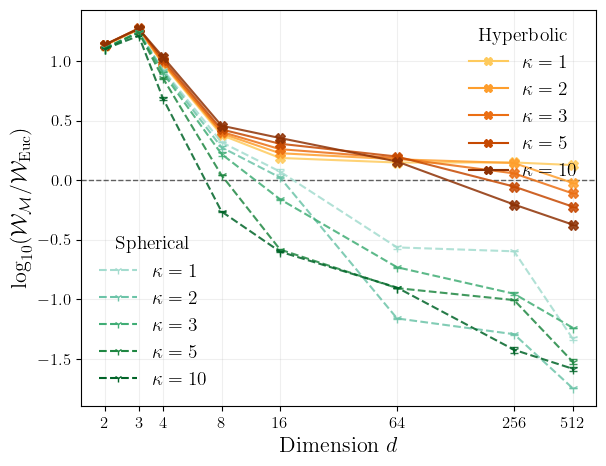

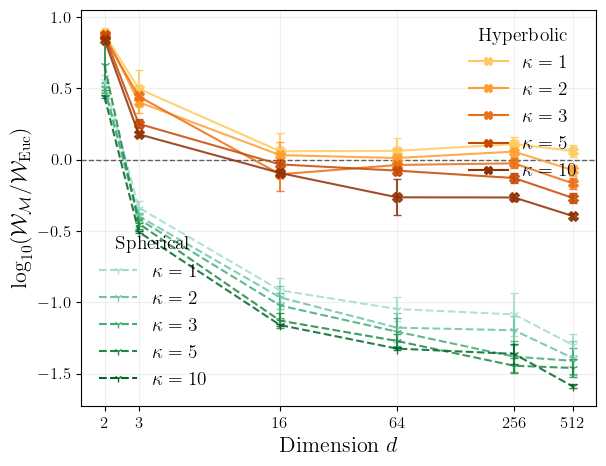

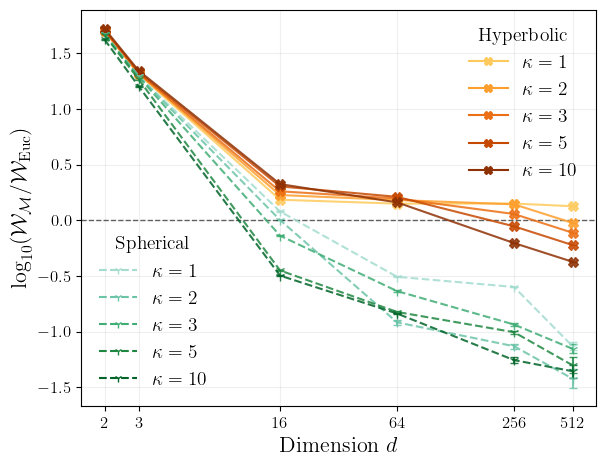

In [15]:
def get_rq3_style_specs(summary):
    marker_map = {
        POINCARE_NAME: "X",
        SPHERE_NAME: "1",
    }

    line_map = {
        POINCARE_NAME: "solid",
        SPHERE_NAME: "dashed",
    }

    manifold_cmap_map = {
        POINCARE_NAME: plt.cm.YlOrBr,
        SPHERE_NAME: plt.cm.BuGn,
    }

    pooled_color_map = {
        POINCARE_NAME: plt.cm.YlOrBr(0.75),
        SPHERE_NAME: plt.cm.BuGn(0.75),
    }

    manifolds = ordered_manifolds(summary[MANIFOLD_COL])
    curvatures = ordered_curvatures(summary[CURV_COL], order=CURVATURE_ORDER)

    curvature_color_map = {}

    for manifold in manifolds:
        manifold_curvatures = ordered_curvatures(
            summary.loc[summary[MANIFOLD_COL].eq(manifold), CURV_COL],
            order=CURVATURE_ORDER,
        )

        cmap = manifold_cmap_map.get(manifold, plt.cm.viridis)
        color_positions = np.linspace(0.35, 0.9, max(len(manifold_curvatures), 1))

        for i, curvature in enumerate(manifold_curvatures):
            curvature_color_map[(manifold, curvature)] = cmap(color_positions[i])

    group_specs = []

    for manifold in manifolds:
        for curvature in curvatures:
            sub = summary[
                summary[MANIFOLD_COL].eq(manifold)
                & summary[CURV_COL].eq(curvature)
            ].copy()

            if sub.empty:
                continue

            group_specs.append({
                "sub": sub,
                "label": rf"$\kappa={nice_curv_label(curvature)}$",
                "color": curvature_color_map.get((manifold, curvature), "C0"),
                "marker": marker_map.get(manifold, "o"),
                "linestyle": line_map.get(manifold, "solid"),
                "manifold": manifold,
                "curvature": curvature,
            })

    return {
        "marker_map": marker_map,
        "line_map": line_map,
        "pooled_color_map": pooled_color_map,
        "manifolds": manifolds,
        "curvatures": curvatures,
        "group_specs": group_specs,
    }


def add_grouped_curvature_legends(
    ax,
    specs,
    hyp_loc="upper right",
    sph_loc="lower left",
    fontsize=14,
):
    if isinstance(specs, dict):
        specs = specs["group_specs"]

    hyp_handles, hyp_labels = [], []
    sph_handles, sph_labels = [], []

    for spec in specs:
        handle = plt.Line2D(
            [0],
            [0],
            color=spec["color"],
            marker=spec["marker"],
            linestyle=spec["linestyle"],
            linewidth=1.5,
            markersize=6,
        )

        label = rf"$\kappa={nice_curv_label(spec['curvature'])}$"

        if spec["manifold"] == POINCARE_NAME:
            hyp_handles.append(handle)
            hyp_labels.append(label)

        elif spec["manifold"] == SPHERE_NAME:
            sph_handles.append(handle)
            sph_labels.append(label)

    hyp_legend = None

    if hyp_handles:
        hyp_legend = ax.legend(
            hyp_handles,
            hyp_labels,
            title="Hyperbolic",
            loc=hyp_loc,
            fontsize=fontsize,
            title_fontsize=fontsize,
            frameon=False,
        )
        ax.add_artist(hyp_legend)

    if sph_handles:
        ax.legend(
            sph_handles,
            sph_labels,
            title="Spherical",
            loc=sph_loc,
            fontsize=fontsize,
            title_fontsize=fontsize,
            frameon=False,
        )

    return hyp_legend


def plot_rq3_dimension_vs_performance(
    summary,
    figsize=(6.4, 5.0),
    hyp_legend_loc="upper right",
    sph_legend_loc="center right",
):
    specs = get_rq3_style_specs(summary)

    fig, ax = plt.subplots(figsize=figsize)

    for spec in specs["group_specs"]:
        sub = spec["sub"].dropna(
            subset=["compare_dim", "log_rel_perf_mean"]
        ).sort_values("compare_dim")

        if sub.empty:
            continue

        ax.errorbar(
            sub["compare_dim"],
            sub["log_rel_perf_mean"],
            yerr=sub["log_rel_perf_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.85,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    format_dimension_axis(ax, summary)

    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(
        r"$\log_{10}\!\left(\mathcal{W}_{\mathcal{M}}"
        r"/\mathcal{W}_{\mathrm{Euc}}\right)$"
    )

    ax.grid(alpha=0.2)

    add_grouped_curvature_legends(
        ax,
        specs["group_specs"],
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=14,
    )

    fig.tight_layout()

    return fig, ax


fig_b, ax_b = plot_rq3_dimension_vs_performance(
    summary_by_curvature_gtg,
    hyp_legend_loc="upper right",
    sph_legend_loc="lower left",
)
plt.show()

fig_b, ax_b = plot_rq3_dimension_vs_performance(
    summary_by_curvature_gr,
    hyp_legend_loc="upper right",
    sph_legend_loc="lower left",
)
plt.show()

fig_b, ax_b = plot_rq3_dimension_vs_performance(
    summary_by_curvature_mog,
    hyp_legend_loc="upper right",
    sph_legend_loc="lower left",
)
plt.show()

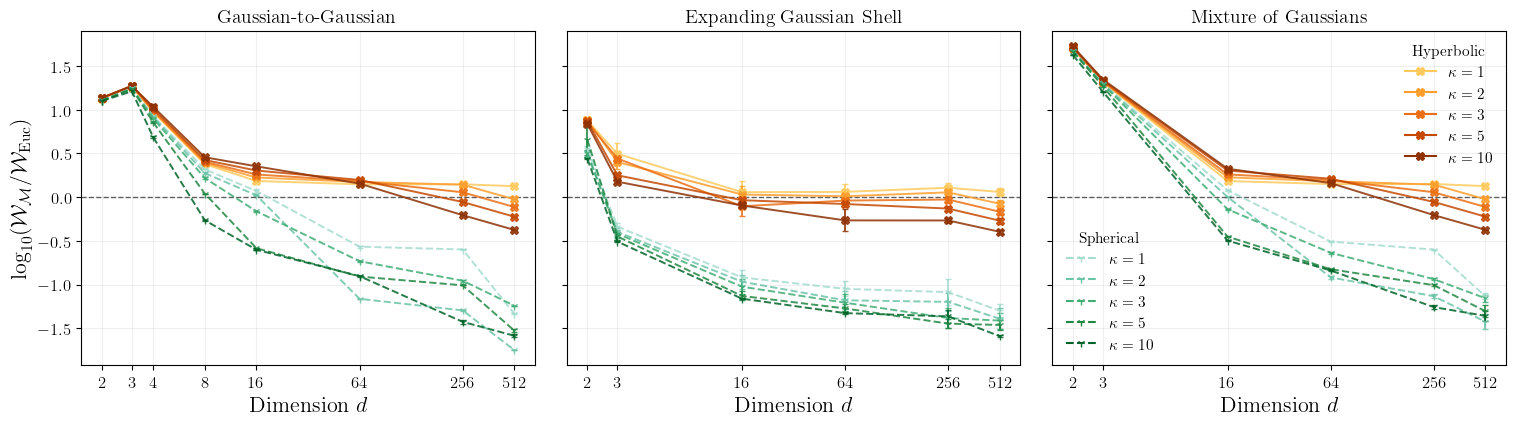

In [16]:
def plot_rq3_three_tasks_side_by_side(
    summaries,
    task_titles,
    figsize=(15.5, 4.6),
    hyp_legend_loc="upper right",
    sph_legend_loc="lower left",
    sharey=True,
):
    fig, axes = plt.subplots(
        1,
        len(summaries),
        figsize=figsize,
        sharey=sharey,
        squeeze=False,
    )

    axes = axes[0]

    for ax, summary, task_title in zip(axes, summaries, task_titles):
        specs = get_rq3_style_specs(summary)

        for spec in specs["group_specs"]:
            sub = spec["sub"].dropna(
                subset=["compare_dim", "log_rel_perf_mean"]
            ).sort_values("compare_dim")

            if sub.empty:
                continue

            ax.errorbar(
                sub["compare_dim"],
                sub["log_rel_perf_mean"],
                yerr=sub["log_rel_perf_err"],
                fmt=spec["marker"],
                color=spec["color"],
                markersize=6,
                capsize=2.5,
                linewidth=1.4,
                alpha=0.85,
                linestyle=spec["linestyle"],
            )

        ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

        format_dimension_axis(ax, summary)

        ax.set_title(task_title)
        ax.set_xlabel(r"Dimension $d$")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel(
        r"$\log_{10}\!\left(\mathcal{W}_{\mathcal{M}}"
        r"/\mathcal{W}_{\mathrm{Euc}}\right)$"
    )

    add_grouped_curvature_legends(
        axes[-1],
        get_rq3_style_specs(summaries[-1])["group_specs"],
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=11,
    )

    fig.tight_layout()
    plt.show()

    return fig, axes


fig_rq3_all, axes_rq3_all = plot_rq3_three_tasks_side_by_side(
    summaries=[
        summary_by_curvature_gtg,
        summary_by_curvature_gr,
        summary_by_curvature_mog,
    ],
    task_titles=[
        "Gaussian-to-Gaussian",
        "Expanding Gaussian Shell",
        "Mixture of Gaussians",
    ],
    figsize=(15.5, 4.6),
    hyp_legend_loc="upper right",
    sph_legend_loc="lower left",
)

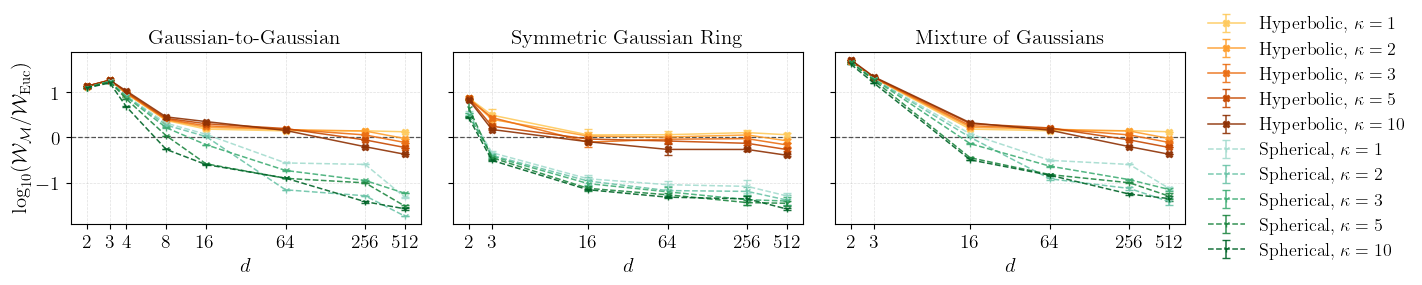

In [17]:
import numpy as np
import matplotlib.pyplot as plt


def plot_rq3_tasks_paper_style(
    summaries,
    task_titles,
    fs = 10,
    savepath = None,
    ylim = None,
    legend = True,
):
    n_tasks = len(summaries)

    fig, axes = plt.subplots(
        1,
        n_tasks,
        figsize = (3 * 1.618 * n_tasks, 3),
        sharey = True,
        squeeze = False,
    )

    axes = axes[0]

    for ax, summary, task_title in zip(axes, summaries, task_titles):
        specs = get_rq3_style_specs(summary)

        for spec in specs["group_specs"]:
            sub = (
                spec["sub"]
                .dropna(subset = ["compare_dim", "log_rel_perf_mean"])
                .sort_values("compare_dim")
            )

            if sub.empty:
                continue

            ax.errorbar(
                sub["compare_dim"],
                sub["log_rel_perf_mean"],
                yerr = sub["log_rel_perf_err"],
                linestyle = spec["linestyle"],
                linewidth = 1.1,
                capsize = 3,
                marker = spec["marker"],
                markersize = 4.5,
                color = spec["color"],
                alpha = 0.9,
                label = f"{display_manifold_name(spec['manifold'])}, $\\kappa={nice_curv_label(spec['curvature'])}$",
            )

        dims = ordered_values_numeric(summary["compare_dim"])

        ax.set_xscale("log", base = 2)
        ax.set_xticks(dims)
        ax.set_xticklabels([nice_dim_label(d) for d in dims], fontsize = fs)

        ax.axhline(
            0,
            color = "black",
            linewidth = 0.9,
            linestyle = "--",
            alpha = 0.65,
        )

        ax.set_title(task_title, fontsize = fs + 1)
        ax.set_xlabel(r"$d$", fontsize = fs + 1)
        ax.tick_params(axis = "y", labelsize = fs)

        if ylim is not None:
            ax.set_ylim(*ylim)

        ax.grid(
            True,
            linewidth = 0.5,
            alpha = 0.4,
            linestyle = "dashed",
        )

    axes[0].set_ylabel(
        r"$\log_{10}(\mathcal{W}_{\mathcal{M}}/\mathcal{W}_{\mathrm{Euc}})$",
        fontsize = fs + 1,
    )

    if legend:
        handles, labels = axes[-1].get_legend_handles_labels()
        axes[-1].legend(
            handles,
            labels,
            fontsize = fs - 1,
            frameon = False,
            loc = "center left",
            bbox_to_anchor = (1.02, 0.5),
        )

    fig.tight_layout()

    if savepath:
        fig.savefig(
            savepath,
            format = "pdf",
            bbox_inches = "tight",
            pad_inches = 0.015,
        )

    plt.show()

    return fig, axes


fig_rq3_all, axes_rq3_all = plot_rq3_tasks_paper_style(
    summaries = [
        summary_by_curvature_gtg,
        summary_by_curvature_gr,
        summary_by_curvature_mog,
    ],
    task_titles = [
        "Gaussian-to-Gaussian",
        "Symmetric Gaussian Ring",
        "Mixture of Gaussians",
    ],
    fs = 14,
    savepath = None,
    ylim = None,
    legend = True,
)

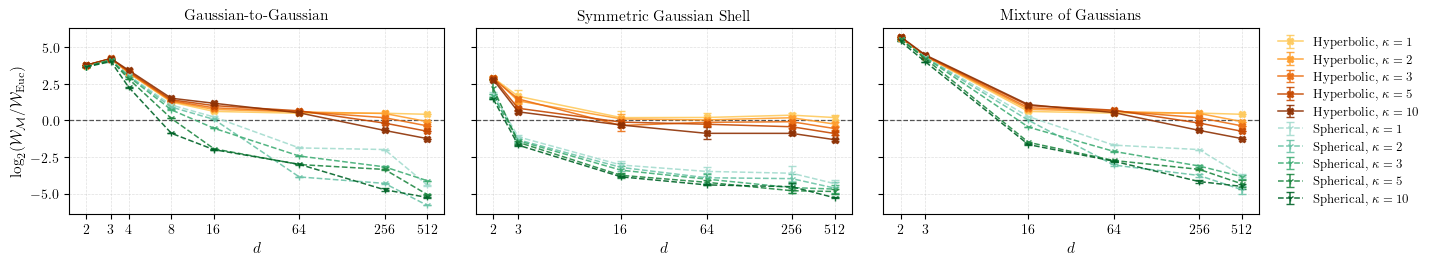

In [18]:
def plot_rq3_tasks_paper_style(
    summaries,
    task_titles,
    fs = 10,
    savepath = None,
    ylim = None,
    legend = True,
    log_base = 10,
):
    n_tasks = len(summaries)

    fig, axes = plt.subplots(
        1,
        n_tasks,
        figsize = (3 * 1.618 * n_tasks, 3),
        sharey = True,
        squeeze = False,
    )

    axes = axes[0]

    log_factor = 1.0 / np.log10(log_base)

    for ax, summary, task_title in zip(axes, summaries, task_titles):
        specs = get_rq3_style_specs(summary)

        for spec in specs["group_specs"]:
            sub = (
                spec["sub"]
                .dropna(subset = ["compare_dim", "log_rel_perf_mean"])
                .sort_values("compare_dim")
            )

            if sub.empty:
                continue

            y = sub["log_rel_perf_mean"] * log_factor
            yerr = sub["log_rel_perf_err"] * log_factor

            ax.errorbar(
                sub["compare_dim"],
                y,
                yerr = yerr,
                linestyle = spec["linestyle"],
                linewidth = 1.1,
                capsize = 3,
                marker = spec["marker"],
                markersize = 4.5,
                color = spec["color"],
                alpha = 0.9,
                label = f"{display_manifold_name(spec['manifold'])}, $\\kappa={nice_curv_label(spec['curvature'])}$",
            )

        dims = ordered_values_numeric(summary["compare_dim"])

        ax.set_xscale("log", base = 2)
        ax.set_xticks(dims)
        ax.set_xticklabels([nice_dim_label(d) for d in dims], fontsize = fs)

        ax.axhline(
            0,
            color = "black",
            linewidth = 0.9,
            linestyle = "--",
            alpha = 0.65,
        )

        ax.set_title(task_title, fontsize = fs + 1, fontweight = "bold")
        ax.set_xlabel(r"$d$", fontsize = fs + 1)
        ax.tick_params(axis = "y", labelsize = fs)

        if ylim is not None:
            ax.set_ylim(*ylim)

        ax.grid(
            True,
            linewidth = 0.5,
            alpha = 0.4,
            linestyle = "dashed",
        )

    axes[0].set_ylabel(
        rf"$\log_{{{log_base}}}(\mathcal{{W}}_{{\mathcal{{M}}}}/\mathcal{{W}}_{{\mathrm{{Euc}}}})$",
        fontsize = fs + 1,
    )

    if legend:
        handles, labels = axes[-1].get_legend_handles_labels()
        axes[-1].legend(
            handles,
            labels,
            fontsize = fs - 1,
            frameon = False,
            loc = "center left",
            bbox_to_anchor = (1.02, 0.5),
        )

    fig.tight_layout()

    if savepath:
        fig.savefig(
            savepath,
            format = "pdf",
            bbox_inches = "tight",
            pad_inches = 0.015,
        )

    plt.show()

    return fig, axes


fig_rq3_all, axes_rq3_all = plot_rq3_tasks_paper_style(
    summaries = [
        summary_by_curvature_gtg,
        summary_by_curvature_gr,
        summary_by_curvature_mog,
    ],
    task_titles = [
        r"Gaussian-to-Gaussian",
        r"Symmetric Gaussian Shell",
        r"Mixture of Gaussians",
    ],
    fs = 10,
    savepath = None,
    ylim = None,
    legend = True,
    log_base = 2,
)

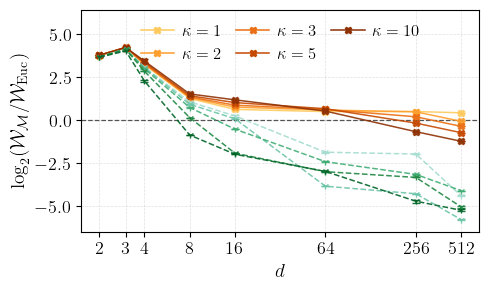

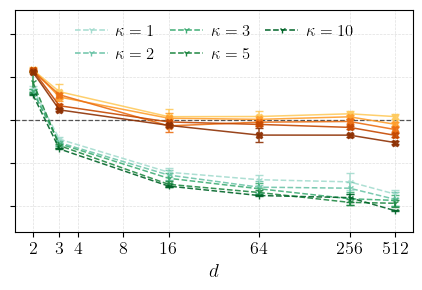

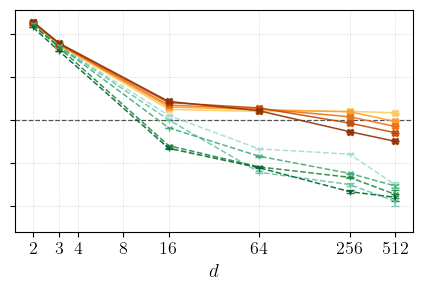

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _get_global_ylim_for_rq3(summaries, log_base = 2, pad_frac = 0.06):
    log_factor = 1.0 / np.log10(log_base)

    vals = []

    for summary in summaries:
        specs = get_rq3_style_specs(summary)

        for spec in specs["group_specs"]:
            sub = (
                spec["sub"]
                .dropna(subset = ["compare_dim", "log_rel_perf_mean"])
                .sort_values("compare_dim")
            )

            if sub.empty:
                continue

            y = sub["log_rel_perf_mean"].to_numpy() * log_factor
            yerr = sub["log_rel_perf_err"].to_numpy() * log_factor

            vals.extend(y - yerr)
            vals.extend(y + yerr)

    vals = np.asarray(vals, dtype = float)
    vals = vals[np.isfinite(vals)]

    ymin = vals.min()
    ymax = vals.max()
    pad = pad_frac * (ymax - ymin)

    return ymin - pad, ymax + pad


def _get_global_dims_for_rq3(summaries):
    dims = []

    for summary in summaries:
        dims.extend(ordered_values_numeric(summary["compare_dim"]))

    return sorted(set(dims))


def _make_internal_legend(
    ax,
    specs,
    manifold,
    fs,
    loc = "upper center",
    bbox_to_anchor = (0.5, 0.98),
    ncol = 3,
):
    handles = []
    used_curvatures = []

    for spec in specs["group_specs"]:
        if spec["manifold"] != manifold:
            continue

        curvature = spec["curvature"]
        if curvature in used_curvatures:
            continue
        used_curvatures.append(curvature)

        handles.append(
            Line2D(
                [0],
                [0],
                color = spec["color"],
                marker = spec["marker"],
                linestyle = spec["linestyle"],
                linewidth = 1.1,
                markersize = 4.5,
                label = rf"$\kappa = {nice_curv_label(curvature)}$",
            )
        )

    if handles:
        ax.legend(
            handles = handles,
            loc = loc,
            bbox_to_anchor = bbox_to_anchor,
            ncol = ncol,
            fontsize = fs - 1,
            frameon = False,
            columnspacing = 0.9,
            handletextpad = 0.45,
            borderaxespad = 0.2,
        )


def plot_rq3_single_task_paper_style(
    summary,
    fs = 10,
    savepath = None,
    ylim = None,
    dims = None,
    show_ylabel = True,
    show_yticklabels = True,
    log_base = 2,
    hyper_legend = False,
    sphere_legend = False,
    hyper_legend_ncol = 3,
    sphere_legend_ncol = 3,
):
    fig, ax = plt.subplots(figsize = (3 * 1.618, 3))

    log_factor = 1.0 / np.log10(log_base)
    specs = get_rq3_style_specs(summary)

    for spec in specs["group_specs"]:
        sub = (
            spec["sub"]
            .dropna(subset = ["compare_dim", "log_rel_perf_mean"])
            .sort_values("compare_dim")
        )

        if sub.empty:
            continue

        y = sub["log_rel_perf_mean"] * log_factor
        yerr = sub["log_rel_perf_err"] * log_factor

        ax.errorbar(
            sub["compare_dim"],
            y,
            yerr = yerr,
            linestyle = spec["linestyle"],
            linewidth = 1.1,
            capsize = 3,
            marker = spec["marker"],
            markersize = 4.5,
            color = spec["color"],
            alpha = 0.9,
        )

    if dims is None:
        dims = ordered_values_numeric(summary["compare_dim"])

    ax.set_xscale("log", base = 2)
    ax.set_xticks(dims)
    ax.set_xticklabels([nice_dim_label(d) for d in dims], fontsize = fs)

    ax.axhline(
        0,
        color = "black",
        linewidth = 0.9,
        linestyle = "--",
        alpha = 0.65,
    )

    ax.set_xlabel(r"$d$", fontsize = fs + 1)

    if show_ylabel:
        ax.set_ylabel(
            rf"$\log_{{{log_base}}}(\mathcal{{W}}_{{\mathcal{{M}}}}/\mathcal{{W}}_{{\mathrm{{Euc}}}})$",
            fontsize = fs + 1,
        )
    else:
        ax.set_ylabel("")

    if not show_yticklabels:
        ax.set_yticklabels([])

    ax.tick_params(axis = "y", labelsize = fs)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(
        True,
        linewidth = 0.5,
        alpha = 0.4,
        linestyle = "dashed",
    )

    if hyper_legend:
        _make_internal_legend(
            ax,
            specs,
            POINCARE_NAME,
            fs,
            loc = "upper center",
            bbox_to_anchor = (0.5, 0.98),
            ncol = hyper_legend_ncol,
        )

    if sphere_legend:
        _make_internal_legend(
            ax,
            specs,
            SPHERE_NAME,
            fs,
            loc = "upper center",
            bbox_to_anchor = (0.5, 0.98),
            ncol = sphere_legend_ncol,
        )

    fig.subplots_adjust(left = 0.16, right = 0.98, bottom = 0.22, top = 0.96)

    if savepath:
        fig.savefig(
            savepath,
            format = "pdf",
            pad_inches = 0.015,
        )

    plt.show()

    return fig, ax


summaries = [
    summary_by_curvature_gtg,
    summary_by_curvature_gr,
    summary_by_curvature_mog,
]

global_ylim = _get_global_ylim_for_rq3(
    summaries,
    log_base = 2,
)

global_dims = _get_global_dims_for_rq3(summaries)


fig_gtg, ax_gtg = plot_rq3_single_task_paper_style(
    summary_by_curvature_gtg,
    fs = 13,
    savepath = None,
    ylim = global_ylim,
    dims = global_dims,
    show_ylabel = True,
    show_yticklabels = True,
    log_base = 2,
    hyper_legend = True,
    sphere_legend = False,
    hyper_legend_ncol = 3,
)

fig_gr, ax_gr = plot_rq3_single_task_paper_style(
    summary_by_curvature_gr,
    fs = 13,
    savepath = None,
    ylim = global_ylim,
    dims = global_dims,
    show_ylabel = False,
    show_yticklabels = False,
    log_base = 2,
    hyper_legend = False,
    sphere_legend = True,
    sphere_legend_ncol = 3,
)

fig_mog, ax_mog = plot_rq3_single_task_paper_style(
    summary_by_curvature_mog,
    fs = 13,
    savepath = None,
    ylim = global_ylim,
    dims = global_dims,
    show_ylabel = False,
    show_yticklabels = False,
    log_base = 2,
    hyper_legend = False,
    sphere_legend = False,
)

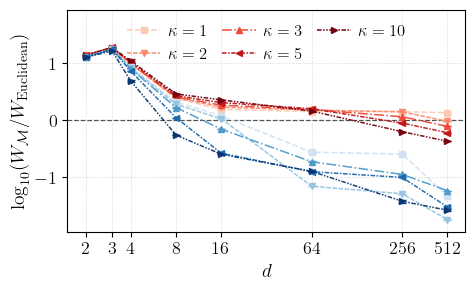

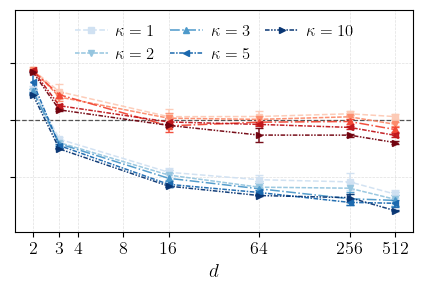

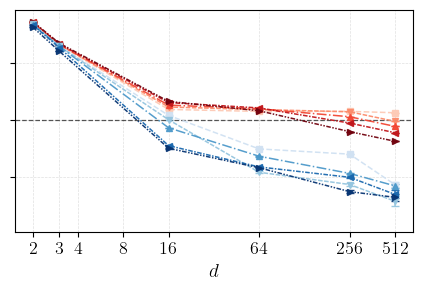

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def get_rq3_style_specs(summary):
    marker_sequence = ["s", "v", "^", "<", ">"]

    linestyle_sequence = [
        "--",                         # dashed
        (0, (3, 1)),                  # densely dashed
        "-.",                         # dashdotted
        (0, (3, 1, 1, 1)),            # densely dashdotted
        (0, (3, 1, 1, 1, 1, 1)),      # densely dashdotdotted
    ]

    manifolds = ordered_manifolds(summary[MANIFOLD_COL])
    curvatures = ordered_curvatures(summary[CURV_COL], order = CURVATURE_ORDER)

    curvature_style_map = {}

    for manifold in manifolds:
        manifold_curvatures = ordered_curvatures(
            summary.loc[summary[MANIFOLD_COL].eq(manifold), CURV_COL],
            order = CURVATURE_ORDER,
        )

        if manifold == POINCARE_NAME:
            colors = plt.cm.Reds(np.linspace(0.20, 0.98, len(manifold_curvatures)))
        elif manifold == SPHERE_NAME:
            colors = plt.cm.Blues(np.linspace(0.20, 0.98, len(manifold_curvatures)))
        else:
            colors = plt.cm.viridis(np.linspace(0.15, 0.98, len(manifold_curvatures)))

        for i, curvature in enumerate(manifold_curvatures):
            curvature_style_map[(manifold, curvature)] = {
                "color": colors[i],
                "marker": marker_sequence[i % len(marker_sequence)],
                "linestyle": linestyle_sequence[i % len(linestyle_sequence)],
            }

    group_specs = []

    for manifold in manifolds:
        for curvature in curvatures:
            sub = summary[
                summary[MANIFOLD_COL].eq(manifold)
                & summary[CURV_COL].eq(curvature)
            ].copy()

            if sub.empty:
                continue

            style = curvature_style_map[(manifold, curvature)]

            group_specs.append({
                "sub": sub,
                "label": rf"$\kappa={nice_curv_label(curvature)}$",
                "color": style["color"],
                "marker": style["marker"],
                "linestyle": style["linestyle"],
                "manifold": manifold,
                "curvature": curvature,
            })

    return {
        "manifolds": manifolds,
        "curvatures": curvatures,
        "group_specs": group_specs,
    }


def _get_global_ylim_for_rq3(summaries, log_base = 10, pad_frac = 0.06):
    log_factor = 1.0 / np.log10(log_base)
    vals = []

    for summary in summaries:
        specs = get_rq3_style_specs(summary)

        for spec in specs["group_specs"]:
            sub = (
                spec["sub"]
                .dropna(subset = ["compare_dim", "log_rel_perf_mean"])
                .sort_values("compare_dim")
            )

            if sub.empty:
                continue

            y = sub["log_rel_perf_mean"].to_numpy() * log_factor
            yerr = sub["log_rel_perf_err"].to_numpy() * log_factor

            vals.extend(y - yerr)
            vals.extend(y + yerr)

    vals = np.asarray(vals, dtype = float)
    vals = vals[np.isfinite(vals)]

    ymin = vals.min()
    ymax = vals.max()
    pad = pad_frac * (ymax - ymin)

    return ymin - pad, ymax + pad


def _get_global_dims_for_rq3(summaries):
    dims = []

    for summary in summaries:
        dims.extend(ordered_values_numeric(summary["compare_dim"]))

    return sorted(set(dims))


def _make_internal_legend(
    ax,
    specs,
    manifold,
    fs,
    loc = "upper center",
    bbox_to_anchor = (0.5, 0.98),
    ncol = 3,
):
    handles = []
    used_curvatures = []

    for spec in specs["group_specs"]:
        if spec["manifold"] != manifold:
            continue

        curvature = spec["curvature"]
        if curvature in used_curvatures:
            continue

        used_curvatures.append(curvature)

        handles.append(
            Line2D(
                [0],
                [0],
                color = spec["color"],
                marker = spec["marker"],
                linestyle = spec["linestyle"],
                linewidth = 1.1,
                markersize = 4.5,
                label = rf"$\kappa={nice_curv_label(curvature)}$",
            )
        )

    if handles:
        ax.legend(
            handles = handles,
            loc = loc,
            bbox_to_anchor = bbox_to_anchor,
            ncol = ncol,
            fontsize = fs - 1,
            frameon = False,
            columnspacing = 0.9,
            handletextpad = 0.45,
            borderaxespad = 0.2,
        )


def plot_rq3_single_task_paper_style(
    summary,
    fs = 10,
    savepath = None,
    ylim = None,
    dims = None,
    show_ylabel = True,
    show_yticklabels = True,
    log_base = 10,
    hyper_legend = False,
    sphere_legend = False,
    hyper_legend_ncol = 3,
    sphere_legend_ncol = 3,
):
    fig, ax = plt.subplots(figsize = (3 * 1.618, 3))

    log_factor = 1.0 / np.log10(log_base)
    specs = get_rq3_style_specs(summary)

    for spec in specs["group_specs"]:
        sub = (
            spec["sub"]
            .dropna(subset = ["compare_dim", "log_rel_perf_mean"])
            .sort_values("compare_dim")
        )

        if sub.empty:
            continue

        y = sub["log_rel_perf_mean"] * log_factor
        yerr = sub["log_rel_perf_err"] * log_factor

        ax.errorbar(
            sub["compare_dim"],
            y,
            yerr = yerr,
            linestyle = spec["linestyle"],
            linewidth = 1.1,
            capsize = 3,
            marker = spec["marker"],
            markersize = 4.5,
            color = spec["color"],
            alpha = 0.95,
        )

    if dims is None:
        dims = ordered_values_numeric(summary["compare_dim"])

    ax.set_xscale("log", base = 2)
    ax.set_xticks(dims)
    ax.set_xticklabels([nice_dim_label(d) for d in dims], fontsize = fs)

    ax.axhline(
        0,
        color = "black",
        linewidth = 0.9,
        linestyle = "--",
        alpha = 0.65,
    )

    ax.set_xlabel(r"$d$", fontsize = fs + 1)

    if show_ylabel:
        ax.set_ylabel(
            rf"$\log_{{{log_base}}}(W_{{\mathcal{{M}}}}/W_{{\mathrm{{Euclidean}}}})$",
            fontsize = fs + 1,
        )
    else:
        ax.set_ylabel("")

    if not show_yticklabels:
        ax.set_yticklabels([])

    ax.tick_params(axis = "y", labelsize = fs)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(
        True,
        linewidth = 0.5,
        alpha = 0.4,
        linestyle = "dashed",
    )

    if hyper_legend:
        _make_internal_legend(
            ax,
            specs,
            POINCARE_NAME,
            fs,
            loc = "upper center",
            bbox_to_anchor = (0.5, 0.98),
            ncol = hyper_legend_ncol,
        )

    if sphere_legend:
        _make_internal_legend(
            ax,
            specs,
            SPHERE_NAME,
            fs,
            loc = "upper center",
            bbox_to_anchor = (0.5, 0.98),
            ncol = sphere_legend_ncol,
        )

    fig.subplots_adjust(left = 0.16, right = 0.98, bottom = 0.22, top = 0.96)

    if savepath:
        fig.savefig(
            savepath,
            format = "pdf",
            bbox_inches = "tight",
            pad_inches = 0.015,
        )

    plt.show()

    return fig, ax


summaries = [
    summary_by_curvature_gtg,
    summary_by_curvature_gr,
    summary_by_curvature_mog,
]

global_ylim = _get_global_ylim_for_rq3(
    summaries,
    log_base = 10,
)

global_dims = _get_global_dims_for_rq3(summaries)


fig_gtg, ax_gtg = plot_rq3_single_task_paper_style(
    summary_by_curvature_gtg,
    fs = 13,
    savepath = None,
    ylim = global_ylim,
    dims = global_dims,
    show_ylabel = True,
    show_yticklabels = True,
    log_base = 10,
    hyper_legend = True,
    sphere_legend = False,
    hyper_legend_ncol = 3,
)

fig_gr, ax_gr = plot_rq3_single_task_paper_style(
    summary_by_curvature_gr,
    fs = 13,
    savepath = None,
    ylim = global_ylim,
    dims = global_dims,
    show_ylabel = False,
    show_yticklabels = False,
    log_base = 10,
    hyper_legend = False,
    sphere_legend = True,
    sphere_legend_ncol = 3,
)

fig_mog, ax_mog = plot_rq3_single_task_paper_style(
    summary_by_curvature_mog,
    fs = 13,
    savepath = None,
    ylim = global_ylim,
    dims = global_dims,
    show_ylabel = False,
    show_yticklabels = False,
    log_base = 10,
    hyper_legend = False,
    sphere_legend = False,
)

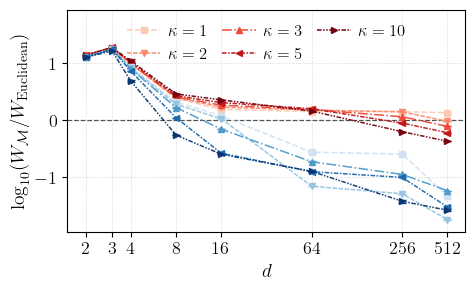

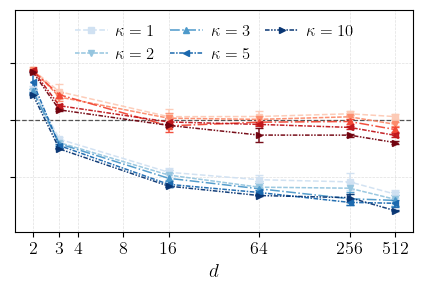

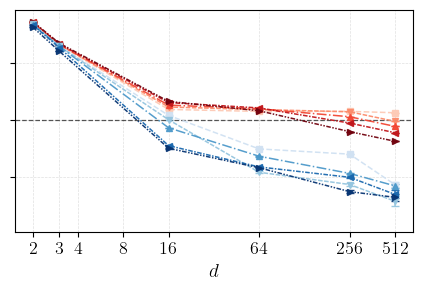

saved:
gtg_wasserstein_relative_dimension.pdf
sgs_wasserstein_relative_dimension.pdf
mog_wasserstein_relative_dimension.pdf


In [33]:
from pathlib import Path

out_dir = Path(".")
log_base = 10

summaries = [
    summary_by_curvature_gtg,
    summary_by_curvature_gr,
    summary_by_curvature_mog,
]

global_ylim = _get_global_ylim_for_rq3(
    summaries,
    log_base = log_base,
)

global_dims = _get_global_dims_for_rq3(summaries)


fig_gtg, ax_gtg = plot_rq3_single_task_paper_style(
    summary_by_curvature_gtg,
    fs = 13,
    savepath = out_dir / "gtg_wasserstein_relative_dimension.pdf",
    ylim = global_ylim,
    dims = global_dims,
    show_ylabel = True,
    show_yticklabels = True,
    log_base = log_base,
    hyper_legend = True,
    sphere_legend = False,
    hyper_legend_ncol = 3,
)

fig_gr, ax_gr = plot_rq3_single_task_paper_style(
    summary_by_curvature_gr,
    fs = 13,
    savepath = out_dir / "sgs_wasserstein_relative_dimension.pdf",
    ylim = global_ylim,
    dims = global_dims,
    show_ylabel = False,
    show_yticklabels = False,
    log_base = log_base,
    hyper_legend = False,
    sphere_legend = True,
    sphere_legend_ncol = 3,
)

fig_mog, ax_mog = plot_rq3_single_task_paper_style(
    summary_by_curvature_mog,
    fs = 13,
    savepath = out_dir / "mog_wasserstein_relative_dimension.pdf",
    ylim = global_ylim,
    dims = global_dims,
    show_ylabel = False,
    show_yticklabels = False,
    log_base = log_base,
    hyper_legend = False,
    sphere_legend = False,
)

print("saved:")
print(out_dir / "gtg_wasserstein_relative_dimension.pdf")
print(out_dir / "sgs_wasserstein_relative_dimension.pdf")
print(out_dir / "mog_wasserstein_relative_dimension.pdf")

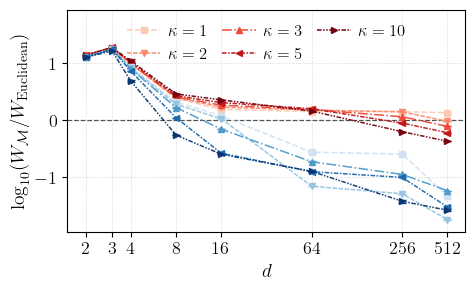

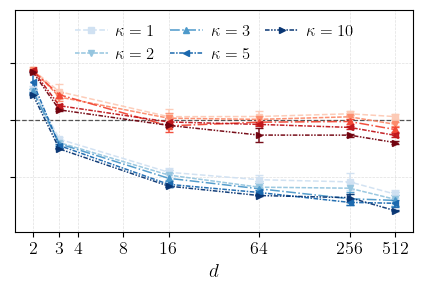

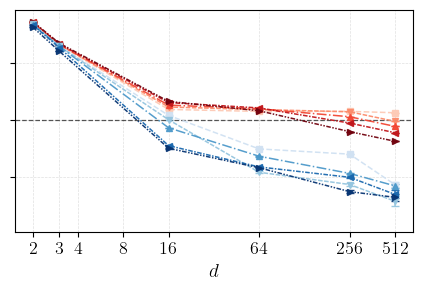

saved:
gtg_wasserstein_relative_dimension.pdf
sgs_wasserstein_relative_dimension.pdf
mog_wasserstein_relative_dimension.pdf


In [21]:
from pathlib import Path
import matplotlib.pyplot as plt

out_dir = Path(".")
log_base = 10

summaries = [
    summary_by_curvature_gtg,
    summary_by_curvature_gr,
    summary_by_curvature_mog,
]

global_ylim = _get_global_ylim_for_rq3(
    summaries,
    log_base = log_base,
)

global_dims = _get_global_dims_for_rq3(summaries)


def save_fixed_canvas(fig, ax, path, show_ylabel):
    fig.set_size_inches(3 * 1.618, 3, forward = True)

    ax.set_position([
        0.18 if show_ylabel else 0.18,
        0.22,
        0.78,
        0.72,
    ])

    fig.savefig(
        path,
        format = "pdf",
        bbox_inches = None,
        pad_inches = 0,
    )


plot_specs = [
    {
        "summary": summary_by_curvature_gtg,
        "filename": "gtg_wasserstein_relative_dimension.pdf",
        "show_ylabel": True,
        "show_yticklabels": True,
        "hyper_legend": True,
        "sphere_legend": False,
    },
    {
        "summary": summary_by_curvature_gr,
        "filename": "sgs_wasserstein_relative_dimension.pdf",
        "show_ylabel": False,
        "show_yticklabels": False,
        "hyper_legend": False,
        "sphere_legend": True,
    },
    {
        "summary": summary_by_curvature_mog,
        "filename": "mog_wasserstein_relative_dimension.pdf",
        "show_ylabel": False,
        "show_yticklabels": False,
        "hyper_legend": False,
        "sphere_legend": False,
    },
]

saved_paths = []

for spec in plot_specs:
    fig, ax = plot_rq3_single_task_paper_style(
        spec["summary"],
        fs = 13,
        savepath = None,
        ylim = global_ylim,
        dims = global_dims,
        show_ylabel = spec["show_ylabel"],
        show_yticklabels = spec["show_yticklabels"],
        log_base = log_base,
        hyper_legend = spec["hyper_legend"],
        sphere_legend = spec["sphere_legend"],
        hyper_legend_ncol = 3,
        sphere_legend_ncol = 3,
    )

    path = out_dir / spec["filename"]
    save_fixed_canvas(fig, ax, path, spec["show_ylabel"])
    saved_paths.append(path)

print("saved:")
for path in saved_paths:
    print(path)

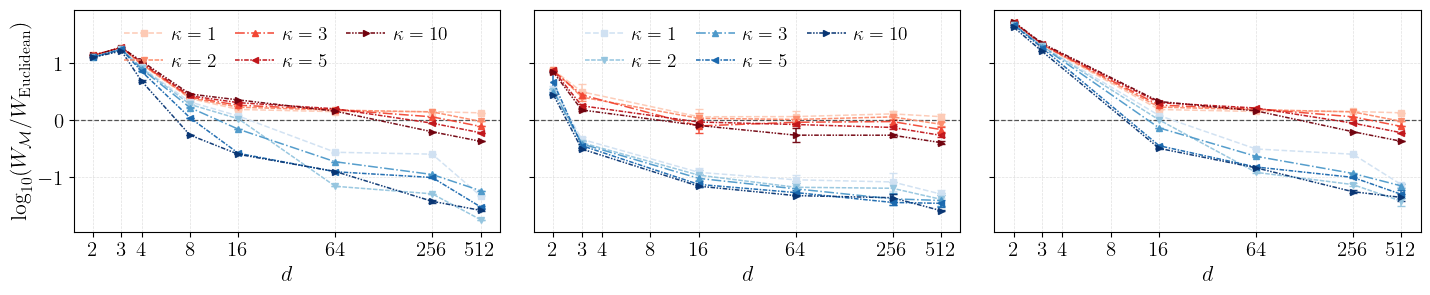

In [22]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _get_global_ylim_for_rq3(summaries, log_base = 10, pad_frac = 0.06):
    log_factor = 1.0 / np.log10(log_base)
    vals = []

    for summary in summaries:
        specs = get_rq3_style_specs(summary)

        for spec in specs["group_specs"]:
            sub = (
                spec["sub"]
                .dropna(subset = ["compare_dim", "log_rel_perf_mean"])
                .sort_values("compare_dim")
            )

            if sub.empty:
                continue

            y = sub["log_rel_perf_mean"].to_numpy() * log_factor
            yerr = sub["log_rel_perf_err"].to_numpy() * log_factor

            vals.extend(y - yerr)
            vals.extend(y + yerr)

    vals = np.asarray(vals, dtype = float)
    vals = vals[np.isfinite(vals)]

    ymin = vals.min()
    ymax = vals.max()
    pad = pad_frac * (ymax - ymin)

    return ymin - pad, ymax + pad


def _get_global_dims_for_rq3(summaries):
    dims = []
    for summary in summaries:
        dims.extend(ordered_values_numeric(summary["compare_dim"]))
    return sorted(set(dims))


def _make_legend_handles(specs, manifold):
    handles = []
    used_curvatures = []

    for spec in specs["group_specs"]:
        if spec["manifold"] != manifold:
            continue

        curvature = spec["curvature"]
        if curvature in used_curvatures:
            continue

        used_curvatures.append(curvature)

        handles.append(
            Line2D(
                [0],
                [0],
                color = spec["color"],
                marker = spec["marker"],
                linestyle = spec["linestyle"],
                linewidth = 1.1,
                markersize = 4.5,
                label = rf"$\kappa={nice_curv_label(curvature)}$",
            )
        )

    return handles


def plot_rq3_combined_paper_style(
    summaries,
    task_titles = None,
    fs = 13,
    log_base = 10,
    savepath = "rq3_wasserstein_relative_dimension_combined.pdf",
    show_titles = False,
):
    global_ylim = _get_global_ylim_for_rq3(summaries, log_base = log_base)
    global_dims = _get_global_dims_for_rq3(summaries)

    fig, axes = plt.subplots(
        1,
        len(summaries),
        figsize = (3 * 1.618 * len(summaries), 3),
        sharey = True,
        squeeze = False,
    )

    axes = axes[0]
    log_factor = 1.0 / np.log10(log_base)

    for panel_idx, (ax, summary) in enumerate(zip(axes, summaries)):
        specs = get_rq3_style_specs(summary)

        for spec in specs["group_specs"]:
            sub = (
                spec["sub"]
                .dropna(subset = ["compare_dim", "log_rel_perf_mean"])
                .sort_values("compare_dim")
            )

            if sub.empty:
                continue

            y = sub["log_rel_perf_mean"] * log_factor
            yerr = sub["log_rel_perf_err"] * log_factor

            ax.errorbar(
                sub["compare_dim"],
                y,
                yerr = yerr,
                linestyle = spec["linestyle"],
                linewidth = 1.1,
                capsize = 3,
                marker = spec["marker"],
                markersize = 4.5,
                color = spec["color"],
                alpha = 0.95,
            )

        ax.set_xscale("log", base = 2)
        ax.set_xticks(global_dims)
        ax.set_xticklabels([nice_dim_label(d) for d in global_dims], fontsize = fs)

        ax.axhline(
            0,
            color = "black",
            linewidth = 0.9,
            linestyle = "--",
            alpha = 0.65,
        )

        ax.set_xlabel(r"$d$", fontsize = fs + 1)
        ax.set_ylim(*global_ylim)

        ax.grid(
            True,
            linewidth = 0.5,
            alpha = 0.4,
            linestyle = "dashed",
        )

        ax.tick_params(axis = "y", labelsize = fs)

        if panel_idx > 0:
            ax.tick_params(labelleft = False)

        if show_titles and task_titles is not None:
            ax.set_title(task_titles[panel_idx], fontsize = fs + 1, fontweight = "bold")

        if panel_idx == 0:
            ax.set_ylabel(
                rf"$\log_{{{log_base}}}(W_{{\mathcal{{M}}}}/W_{{\mathrm{{Euclidean}}}})$",
                fontsize = fs + 1,
            )

        if panel_idx == 0:
            hyp_handles = _make_legend_handles(specs, POINCARE_NAME)
            ax.legend(
                handles = hyp_handles,
                loc = "upper center",
                bbox_to_anchor = (0.5, 0.98),
                ncol = 3,
                fontsize = fs - 1,
                frameon = False,
                columnspacing = 0.9,
                handletextpad = 0.45,
                borderaxespad = 0.2,
            )

        if panel_idx == 1:
            sph_handles = _make_legend_handles(specs, SPHERE_NAME)
            ax.legend(
                handles = sph_handles,
                loc = "upper center",
                bbox_to_anchor = (0.5, 0.98),
                ncol = 3,
                fontsize = fs - 1,
                frameon = False,
                columnspacing = 0.9,
                handletextpad = 0.45,
                borderaxespad = 0.2,
            )

    fig.subplots_adjust(
        left = 0.07,
        right = 0.995,
        bottom = 0.22,
        top = 0.96,
        wspace = 0.08,
    )

    if savepath is not None:
        fig.savefig(
            savepath,
            format = "pdf",
            bbox_inches = None,
            pad_inches = 0,
        )

    plt.show()

    return fig, axes


fig_rq3_combined, axes_rq3_combined = plot_rq3_combined_paper_style(
    summaries = [
        summary_by_curvature_gtg,
        summary_by_curvature_gr,
        summary_by_curvature_mog,
    ],
    task_titles = [
        "Gaussian-to-Gaussian",
        "Symmetric Gaussian Shell",
        "Mixture of Gaussians",
    ],
    fs = 15,
    log_base = 10,
    savepath = "rq4_wasserstein_relative_dimension_combined.pdf",
    show_titles = False,
)

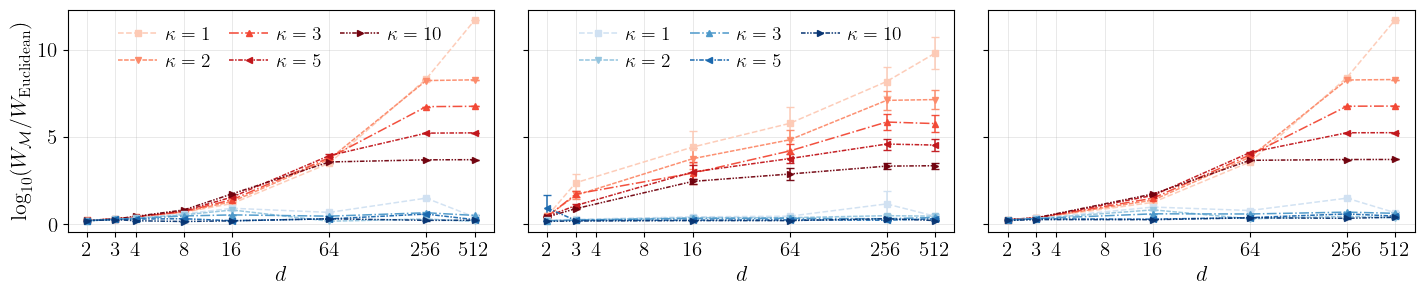

In [26]:
def plot_rq4_perf_paper_style(
    summaries,
    task_titles=None,
    fs=13,
    log_base=10,
    savepath="rq4_wasserstein_non_rel_dimension_combined.pdf",
    show_titles=False,
):
    global_dims = _get_global_dims_for_rq3(summaries)

    fig, axes = plt.subplots(
        1,
        len(summaries),
        figsize=(3 * 1.618 * len(summaries), 3),
        sharey=True,
        squeeze=False,
    )

    axes = axes[0]
    log_factor = 1.0 / np.log10(log_base)

    # collect ALL y values across all panels for a shared scale
    all_y = []

    processed_panels = []

    for summary in summaries:
        specs = get_rq3_style_specs(summary)

        panel_vals = []

        for spec in specs["group_specs"]:
            sub = (
                spec["sub"]
                .dropna(subset=["compare_dim", "perf_mean"])
                .sort_values("compare_dim")
            )

            if sub.empty:
                continue

            y = sub["perf_mean"] * log_factor
            yerr = sub["perf_err"] * log_factor

            panel_vals.extend(y.values)

            processed_panels.append((spec, sub, y, yerr, summary))

        all_y.extend(panel_vals)

    # global shared y-limits (no Euclidean midline, no forced zero centering)
    all_y = np.asarray(all_y)
    all_y = all_y[np.isfinite(all_y)]

    if len(all_y) > 0:
        y_min, y_max = np.min(all_y), np.max(all_y)
        pad = 0.05 * (y_max - y_min + 1e-12)
        global_ylim = (y_min - pad, y_max + pad)
    else:
        global_ylim = None

    # actually plot
    for panel_idx, (ax, summary) in enumerate(zip(axes, summaries)):

        specs = get_rq3_style_specs(summary)

        for spec in specs["group_specs"]:
            sub = (
                spec["sub"]
                .dropna(subset=["compare_dim", "perf_mean"])
                .sort_values("compare_dim")
            )

            if sub.empty:
                continue

            y = sub["perf_mean"] * log_factor
            yerr = sub["perf_err"] * log_factor

            ax.errorbar(
                sub["compare_dim"],
                y,
                yerr=yerr,
                linestyle=spec["linestyle"],
                linewidth=1.1,
                capsize=3,
                marker=spec["marker"],
                markersize=4.5,
                color=spec["color"],
                alpha=0.95,
            )

        ax.set_xscale("log", base=2)
        ax.set_xticks(global_dims)
        ax.set_xticklabels([nice_dim_label(d) for d in global_dims], fontsize=fs)

        ax.set_xlabel(r"$d$", fontsize=fs + 1)

        if global_ylim is not None:
            ax.set_ylim(*global_ylim)

        ax.grid(True, linewidth=0.5, alpha=0.4, linestyle="solid")
        ax.tick_params(axis="y", labelsize=fs)

        if panel_idx > 0:
            ax.tick_params(labelleft=False)

        if show_titles and task_titles is not None:
            ax.set_title(task_titles[panel_idx], fontsize=fs + 1, fontweight="bold")

        if panel_idx == 0:
            ax.set_ylabel(
                rf"$\log_{{{log_base}}}(W_{{\mathcal{{M}}}}/W_{{\mathrm{{Euclidean}}}})$",
                fontsize=fs + 1,
            )

        # no axhline(0) anywhere → removes Euclidean mid-line

        if panel_idx == 0:
            hyp_handles = _make_legend_handles(specs, POINCARE_NAME)
            ax.legend(
                handles=hyp_handles,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.98),
                ncol=3,
                fontsize=fs - 1,
                frameon=False,
                columnspacing=0.9,
                handletextpad=0.45,
                borderaxespad=0.2,
            )

        if panel_idx == 1:
            sph_handles = _make_legend_handles(specs, SPHERE_NAME)
            ax.legend(
                handles=sph_handles,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.98),
                ncol=3,
                fontsize=fs - 1,
                frameon=False,
                columnspacing=0.9,
                handletextpad=0.45,
                borderaxespad=0.2,
            )

    fig.subplots_adjust(
        left=0.07,
        right=0.995,
        bottom=0.22,
        top=0.96,
        wspace=0.08,
    )

    if savepath is not None:
        fig.savefig(savepath, format="pdf", bbox_inches=None, pad_inches=0)

    plt.show()

    return fig, axes

fig_rq4_perf, axes_rq4_perf = plot_rq4_perf_paper_style(
    summaries=[
        summary_by_curvature_gtg,
        summary_by_curvature_gr,
        summary_by_curvature_mog,
    ],
    task_titles=[
        "Gaussian-to-Gaussian",
        "Symmetric Gaussian Shell",
        "Mixture of Gaussians",
    ],
    fs=15,
    log_base=10,
    savepath="rq4_wasserstein_non_rel_dimension_combined.pdf",
    show_titles=False,
)